# CCO07: Starts fresh again

In [2]:
import scanpy as sc
import matplotlib.pyplot as plt
import glob
import numpy as np
import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import anndata
import os
import glob
import scipy

In [3]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO07

In [4]:
PREV_DIR = "/home/herbert/PyProjects/cocultured_organ/workspace/CCO06"
WORK_DIR = "/home/herbert/PyProjects/cocultured_organ/workspace/CCO07"

# 1. Change label and start from doublet filtered

In [4]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/adata/doublet_filtered
# ln -s /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/adata/doublet_filtered/* /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/adata/doublet_filtered

mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/adata/cell_type_labelled

In [5]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/dotplots
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/umaps

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)
/tmp/ipykernel_1592917/2970865849.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pat.obs['leiden'][0] = j
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/anndata/_core/anndata.py:1763: FutureWarning: The AnnData.concatenate method is deprecated in favour of the anndata.concat function. Please use anndata.concat instead.

See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  warnings.warn(
/tmp/ipykernel_1592917/2970865849.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See th

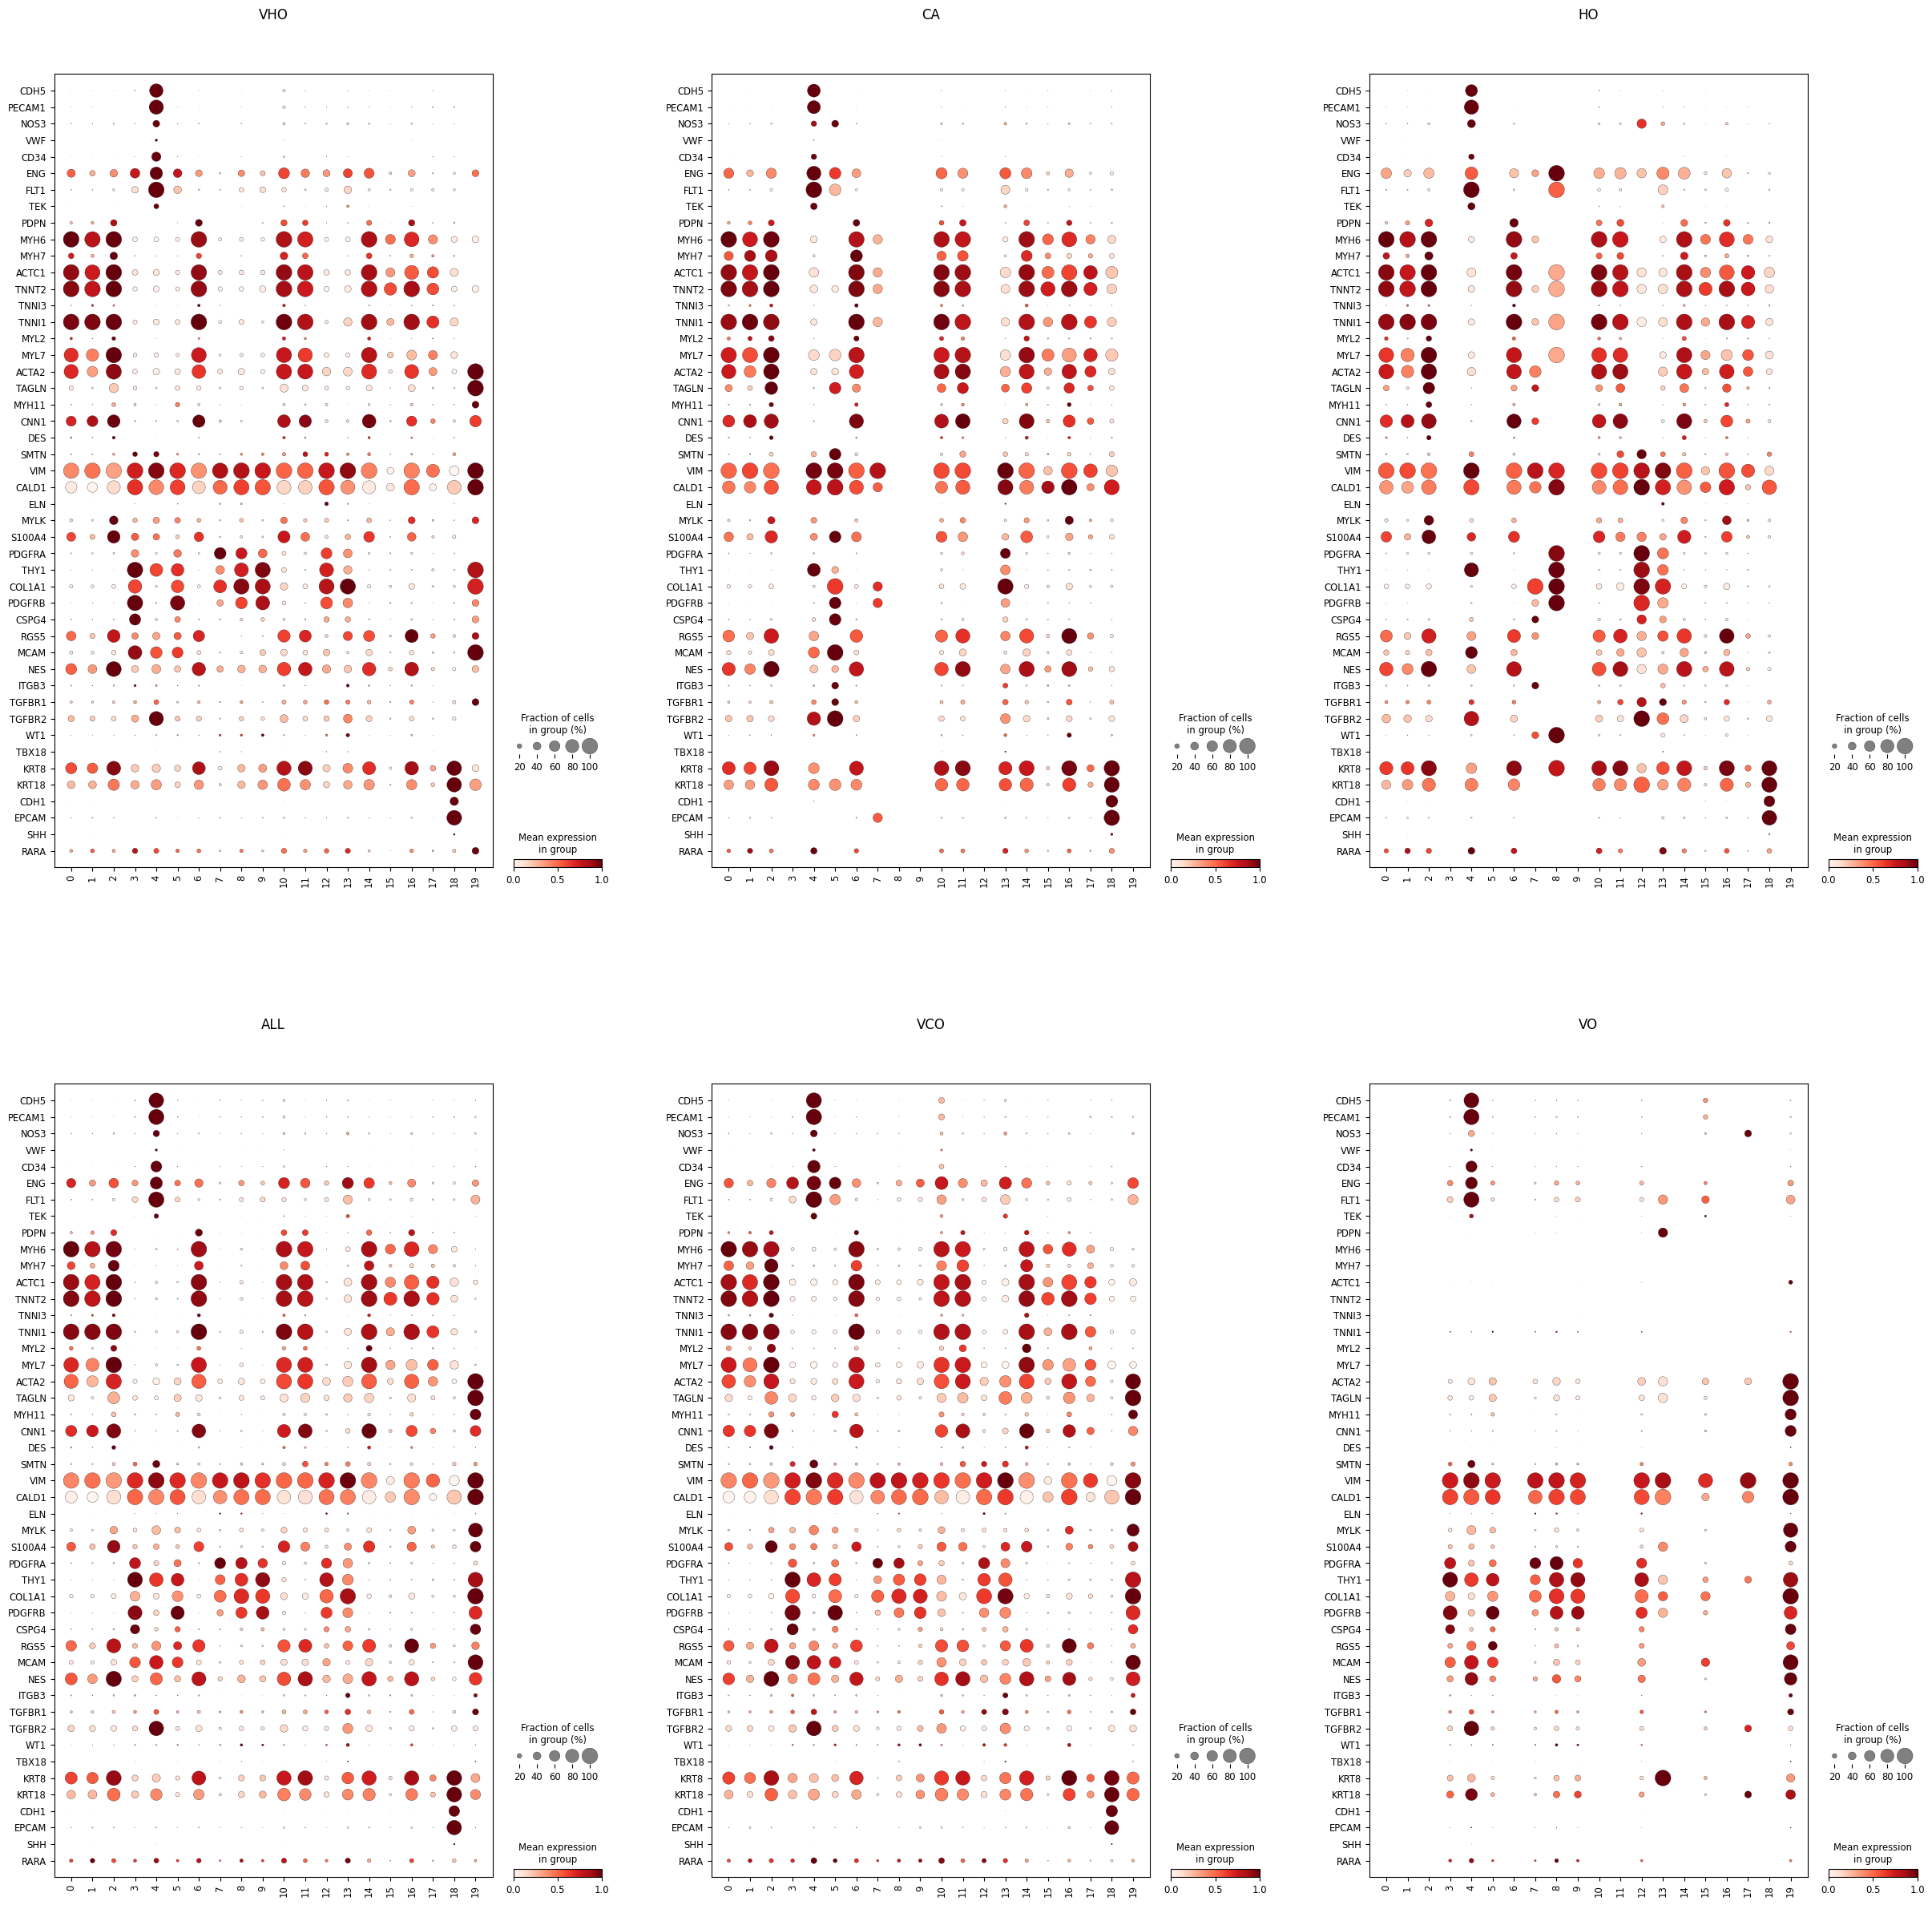

In [6]:
marker_dict = ['CDH5', 'PECAM1', 'NOS3', 'VWF', 'CD34', 'ENG', 'FLT1', 'TEK', 'PDPN', 'MYH6', 
               'MYH7', 'ACTC1', 'TNNT2', 'TNNI3', 'TNNI1', 'MYL2', 'MYL7', 'ACTA2', 'TAGLN', 'MYH11', 
               'CNN1', 'DES', 'SMTN', 'VIM', 'CALD1', 'ELN', 'MYLK', 'S100A4', 'PDGFRA', 'THY1', 
               'COL1A1', 'PDGFRB', 'CSPG4', 'RGS5', 'MCAM', 'NES', 'ITGB3', 'TGFBR1', 'TGFBR2', 'WT1', 
               'TBX18', 'KRT8', 'KRT18', 'CDH1', 'EPCAM', 'SHH', 'RARA']

fig, axs = plt.subplots(2, 3, figsize=(30,30), layout="constrained")
axs = axs.flatten()

for i, d1 in enumerate(glob.glob(f'{WORK_DIR}/adata/doublet_filtered/*.h5ad')):
    sample_name = d1.split('/')[-1].strip('.h5ad')
    adata = sc.read_h5ad(d1)
    
    adata.obs['leiden'] = adata.obs['leiden'].astype("int")
    for j in range(0, 20):
        if (adata.obs['leiden'] == j).any():
            continue
        else:
            pat = adata[0].copy()
            pat.obs['leiden'][0] = j
            pat.X.data[:] = 0
            adata = adata.concatenate(pat, batch_key='batch')
    adata.obs['leiden'] = adata.obs['leiden'].astype("category")
    
    sc.pl.dotplot(adata, marker_dict, groupby="leiden", standard_scale="var", ax=axs[i], title=sample_name, show=False, swap_axes=True)
    
plt.savefig(f'{WORK_DIR}/dotplots/dotplot_leiden.png')
plt.show()

In [7]:
samples = ['ALL','VO','HO','CA','VHO','VCO']
samples_old = ['ALL','BVO','HO','CM3O','BHO','CM3B']

# celltypes_dict = {
#     '0': 'CM', 
#     '1': 'CM',
#     '2': 'CM',
#     '3': 'PR',
#     '4': 'EN',
#     '5': 'PR',
#     '6': 'CM',
#     '7': 'FB',
#     '8': 'FB',
#     '9': 'FB',
#     '10': 'CM',
#     '11': 'CM',
#     '12': 'FB',
#     '13': 'SM',
#     '14': 'CM',
#     '15': 'UN',
#     '16': 'CM',
#     '17': 'UN',
#     '18': 'EP',
#     '19': 'SM',
# }

celltypes_dict = {
    '0': 'CM', 
    '1': 'CM',
    '2': 'CM',
    '3': 'MU',
    '4': 'EN',
    '5': 'MU',
    '6': 'CM',
    '7': 'MU',
    '8': 'MU',
    '9': 'MU',
    '10': 'CM',
    '11': 'CM',
    '12': 'MU',
    '13': 'MU',
    '14': 'CM',
    '15': 'UN',
    '16': 'CM',
    '17': 'UN',
    '18': 'EP',
    '19': 'MU',
}

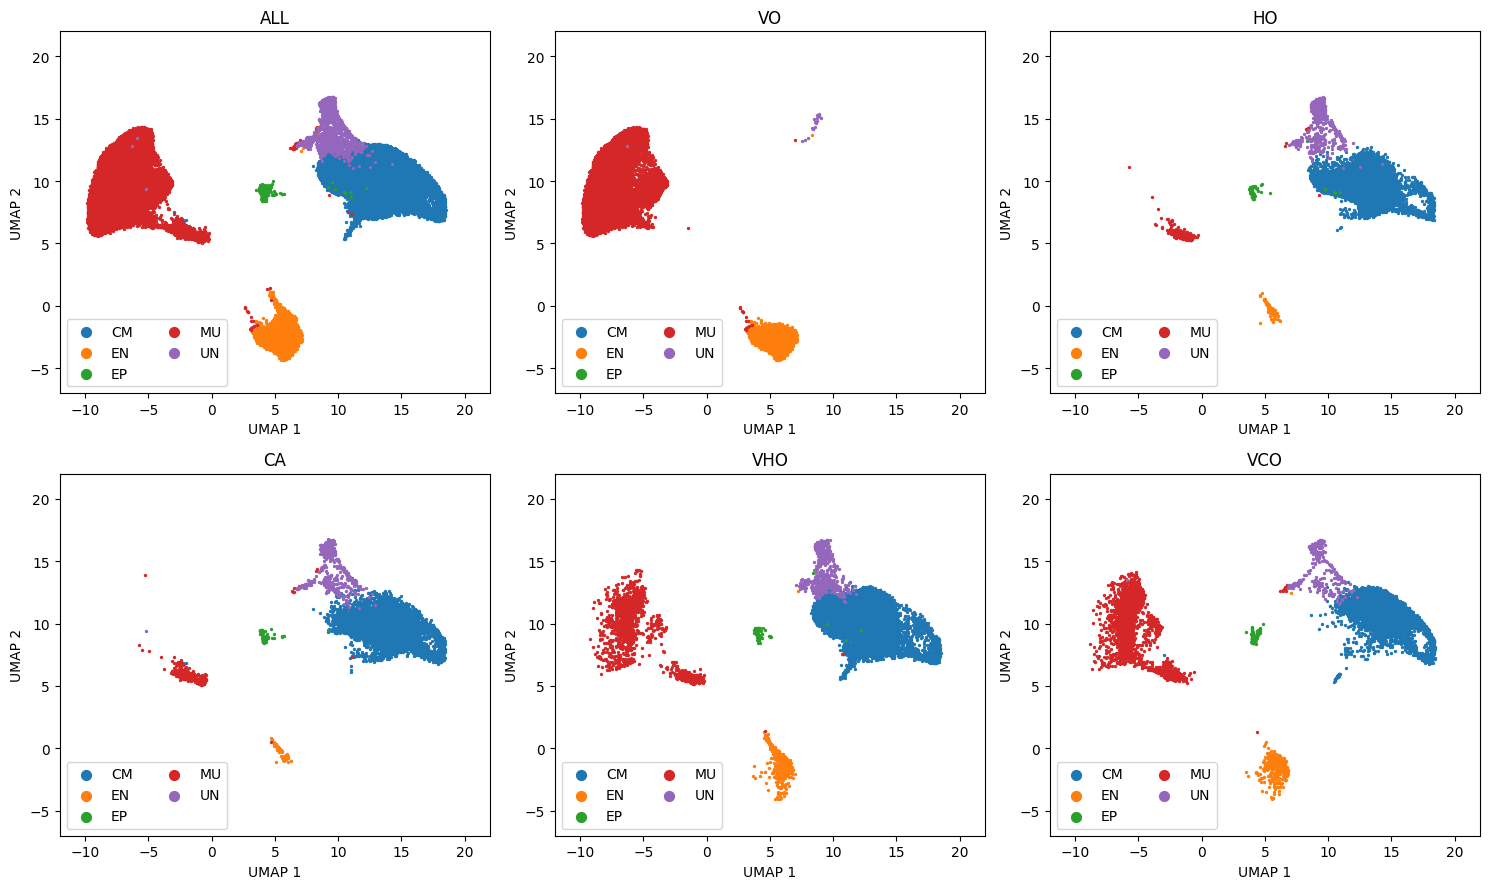

In [13]:
fig, axs = plt.subplots(2, 3, figsize=(15,9))
axs = axs.flatten()

# cell_types = ['CM','PR','FB','SM','EP','EN','UN']
cell_types = ['CM','EN','EP','MU','UN']
cmap = plt.get_cmap('viridis')
colors = plt.get_cmap('tab10').colors

batch_mapper = dict(zip(samples_old, samples))

for i, sample in enumerate(samples):
    
    adata = sc.read_h5ad(f'{WORK_DIR}/adata/doublet_filtered/{sample}.h5ad')
    adata.obs['cell_type'] = adata.obs['leiden'].map(celltypes_dict)
    
    adata.obs['batch'] = adata.obs['batch'].astype('str')
    adata.obs['batch'] = adata.obs['batch'].map(batch_mapper)
    adata.obs['batch'] = adata.obs['batch'].astype('category')
    
    adata.write(f'{WORK_DIR}/adata/cell_type_labelled/{sample}.h5ad')
    
    for j, ct in enumerate(cell_types):
        axs[i].scatter(
            adata.obsm['X_umap'][adata.obs['cell_type'] == ct, 0], 
            adata.obsm['X_umap'][adata.obs['cell_type'] == ct, 1], 
            label=ct, 
            color=colors[j], s=2)
        
    axs[i].legend(loc='lower left', markerscale=5, ncol=2)
    axs[i].set_xlabel('UMAP 1')
    axs[i].set_ylabel('UMAP 2')
    axs[i].set_title(sample)
    axs[i].set_xlim([-12, 22])
    axs[i].set_ylim([-7, 22])
    
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/umaps/cell_type_labelled.png')
plt.show()

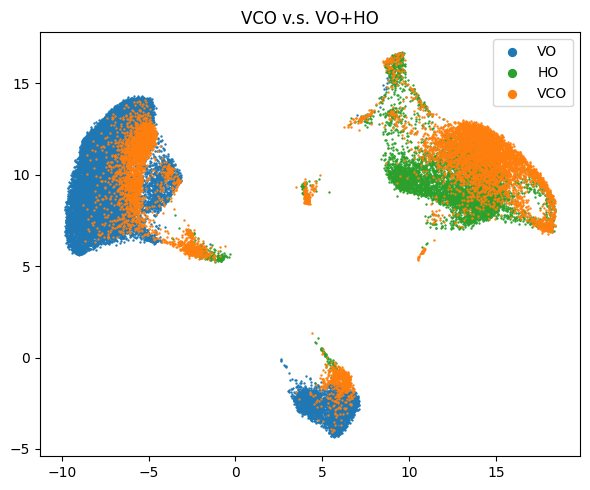

In [18]:
adata_all = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_labelled/ALL.h5ad")
adata_vo = adata_all[adata_all.obs['batch'] == "VO"]
adata_ho = adata_all[adata_all.obs['batch'] == "HO"]
adata_vco = adata_all[adata_all.obs['batch'] == "VCO"]

fig, ax = plt.subplots(1, 1, figsize=(6,5))

colors = plt.get_cmap('tab10').colors
ax.scatter(adata_vo.obsm['X_umap'][:,0], adata_vo.obsm['X_umap'][:,1], color=colors[0], label="VO", s=0.5)
ax.scatter(adata_ho.obsm['X_umap'][:,0], adata_ho.obsm['X_umap'][:,1], color=colors[2], label="HO", s=0.5)
ax.scatter(adata_vco.obsm['X_umap'][:,0], adata_vco.obsm['X_umap'][:,1], color=colors[1], label="VCO", s=0.5)
ax.set_title("VCO v.s. VO+HO")
ax.legend(markerscale=8)

plt.tight_layout()
plt.show()

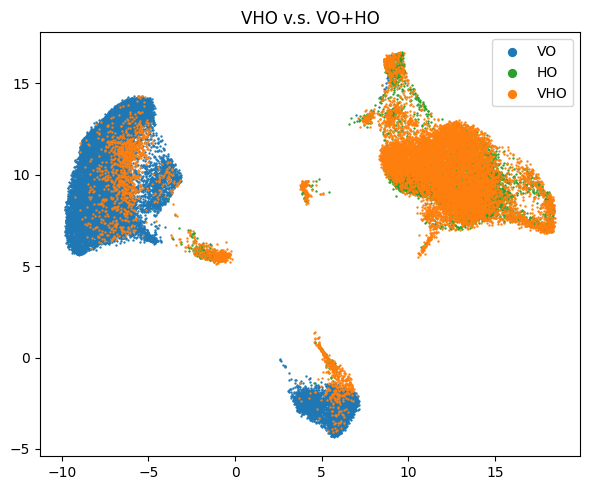

In [19]:
adata_all = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_labelled/ALL.h5ad")
adata_vo = adata_all[adata_all.obs['batch'] == "VO"]
adata_ho = adata_all[adata_all.obs['batch'] == "HO"]
adata_vco = adata_all[adata_all.obs['batch'] == "VHO"]

fig, ax = plt.subplots(1, 1, figsize=(6,5))

colors = plt.get_cmap('tab10').colors
ax.scatter(adata_vo.obsm['X_umap'][:,0], adata_vo.obsm['X_umap'][:,1], color=colors[0], label="VO", s=0.5)
ax.scatter(adata_ho.obsm['X_umap'][:,0], adata_ho.obsm['X_umap'][:,1], color=colors[2], label="HO", s=0.5)
ax.scatter(adata_vco.obsm['X_umap'][:,0], adata_vco.obsm['X_umap'][:,1], color=colors[1], label="VHO", s=0.5)
ax.set_title("VHO v.s. VO+HO")
ax.legend(markerscale=8)

plt.tight_layout()
plt.show()

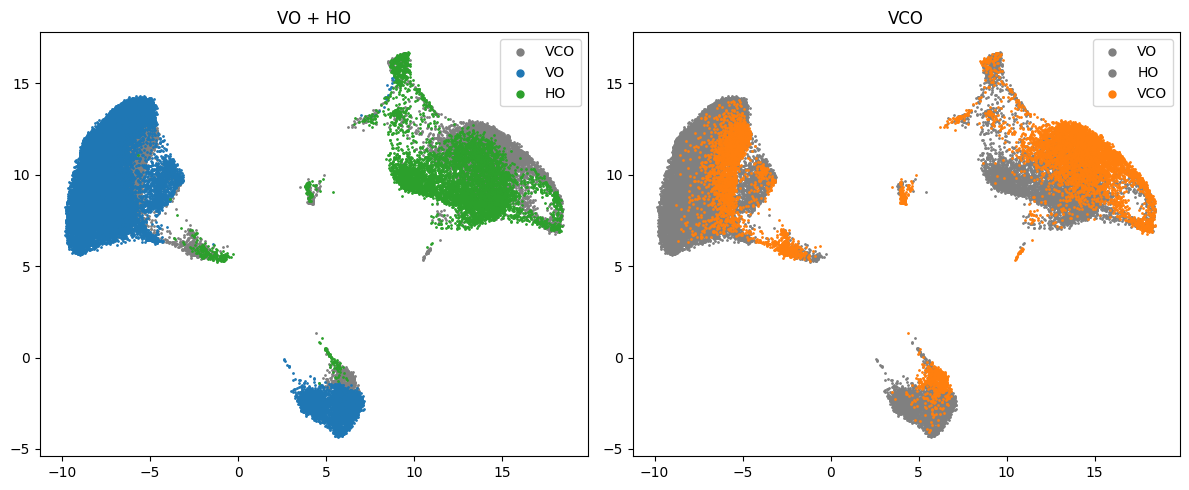

In [21]:
adata_all = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_labelled/ALL.h5ad")
adata_vo = adata_all[adata_all.obs['batch'] == "VO"]
adata_ho = adata_all[adata_all.obs['batch'] == "HO"]
adata_vco = adata_all[adata_all.obs['batch'] == "VCO"]

fig, axs = plt.subplots(1, 2, figsize=(12,5))

axs[0].scatter(adata_vco.obsm['X_umap'][:,0], adata_vco.obsm['X_umap'][:,1], color="grey", label="VCO", s=1)
axs[0].scatter(adata_vo.obsm['X_umap'][:,0], adata_vo.obsm['X_umap'][:,1], color=colors[0], label="VO", s=1)
axs[0].scatter(adata_ho.obsm['X_umap'][:,0], adata_ho.obsm['X_umap'][:,1], color=colors[2], label="HO", s=1)
axs[0].set_title("VO + HO")
axs[0].legend(markerscale=5)

axs[1].scatter(adata_vo.obsm['X_umap'][:,0], adata_vo.obsm['X_umap'][:,1], color="grey", label="VO", s=1)
axs[1].scatter(adata_ho.obsm['X_umap'][:,0], adata_ho.obsm['X_umap'][:,1], color="grey", label="HO", s=1)
axs[1].scatter(adata_vco.obsm['X_umap'][:,0], adata_vco.obsm['X_umap'][:,1], color=colors[1], label="VCO", s=1)
axs[1].set_title("VCO")
axs[1].legend(markerscale=5)

plt.tight_layout()
plt.show()

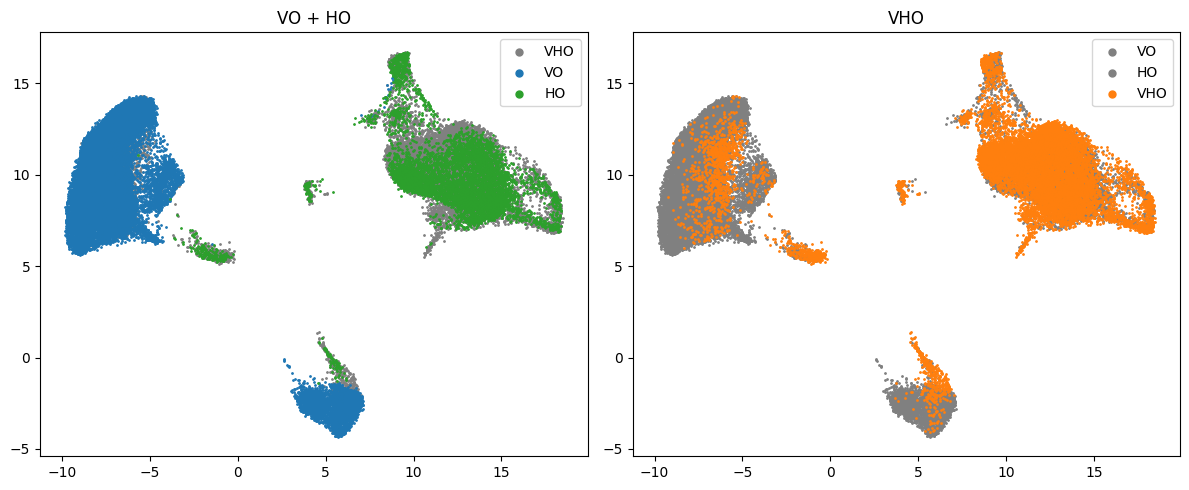

In [22]:
adata_all = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_labelled/ALL.h5ad")
adata_vo = adata_all[adata_all.obs['batch'] == "VO"]
adata_ho = adata_all[adata_all.obs['batch'] == "HO"]
adata_vco = adata_all[adata_all.obs['batch'] == "VHO"]

fig, axs = plt.subplots(1, 2, figsize=(12,5))

axs[0].scatter(adata_vco.obsm['X_umap'][:,0], adata_vco.obsm['X_umap'][:,1], color="grey", label="VHO", s=1)
axs[0].scatter(adata_vo.obsm['X_umap'][:,0], adata_vo.obsm['X_umap'][:,1], color=colors[0], label="VO", s=1)
axs[0].scatter(adata_ho.obsm['X_umap'][:,0], adata_ho.obsm['X_umap'][:,1], color=colors[2], label="HO", s=1)
axs[0].set_title("VO + HO")
axs[0].legend(markerscale=5)

axs[1].scatter(adata_vo.obsm['X_umap'][:,0], adata_vo.obsm['X_umap'][:,1], color="grey", label="VO", s=1)
axs[1].scatter(adata_ho.obsm['X_umap'][:,0], adata_ho.obsm['X_umap'][:,1], color="grey", label="HO", s=1)
axs[1].scatter(adata_vco.obsm['X_umap'][:,0], adata_vco.obsm['X_umap'][:,1], color=colors[1], label="VHO", s=1)
axs[1].set_title("VHO")
axs[1].legend(markerscale=5)

plt.tight_layout()
plt.show()

# 2. Celltype split and recluster

In [4]:
%%bash
rm -r /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/adata/cell_type_split
rm -r /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/adata/cell_type_subclustered
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/adata/cell_type_split
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/adata/cell_type_subclustered

In [4]:
# cell_types = ['CM','PR','FB','SM','EP','EN','UN']
cell_types = ['CM','EN','EP','MU','UN']
samples = ['ALL','VO','HO','CA','VHO','VCO']
samples_old = ['ALL','BVO','HO','CM3O','BHO','CM3B']

MIN_CELL_COUNT = 10

In [5]:
adata_all = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_labelled/ALL.h5ad")
for ct in cell_types:
    adata = adata_all[adata_all.obs['cell_type'] == ct]
    adata.write_h5ad(f"{WORK_DIR}/adata/cell_type_split/{ct}.h5ad")

## 2.1 cardiomyocyte

In [8]:
ct = "CM"
adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_split/{ct}.h5ad")
sc.tl.leiden(adata, resolution=0.5, random_state=42)

adata.obs['leiden'] = adata.obs['leiden'].astype("int")
old_leiden = adata.obs['leiden'].unique()
old_leiden.sort()
for i, l in enumerate(old_leiden):
    adata.obs['leiden'].loc[adata.obs['leiden'] == l] = i
adata.obs['leiden'] = adata.obs['leiden'].astype("str")
adata.obs['leiden'] = adata.obs['leiden'].astype("category")
adata.obs['leiden']

/tmp/ipykernel_3752030/386624598.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata.obs['leiden'].loc[adata.obs['leiden'] == l] = i


AAACCCAAGAAGGGAT-1-0    0
AAACCCAAGTCAGGGT-1-0    1
AAACCCACATCCAACA-1-0    1
AAACCCAGTAGATGTA-1-0    1
AAACCCAGTAGTACGG-1-0    1
                       ..
TTTGTTGAGACTGGGT-1-4    1
TTTGTTGAGATTGACA-1-4    0
TTTGTTGAGGGTACGT-1-4    0
TTTGTTGTCATGCCGG-1-4    3
TTTGTTGTCGTTGCCT-1-4    3
Name: leiden, Length: 25365, dtype: category
Categories (5, object): ['0', '1', '2', '3', '4']

In [9]:
ct = "CM"
adata = adata[adata.obs['leiden'] != "4"]
adata.obs['leiden']

AAACCCAAGAAGGGAT-1-0    0
AAACCCAAGTCAGGGT-1-0    1
AAACCCACATCCAACA-1-0    1
AAACCCAGTAGATGTA-1-0    1
AAACCCAGTAGTACGG-1-0    1
                       ..
TTTGTTGAGACTGGGT-1-4    1
TTTGTTGAGATTGACA-1-4    0
TTTGTTGAGGGTACGT-1-4    0
TTTGTTGTCATGCCGG-1-4    3
TTTGTTGTCGTTGCCT-1-4    3
Name: leiden, Length: 25229, dtype: category
Categories (4, object): ['0', '1', '2', '3']

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_utils.py:432: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


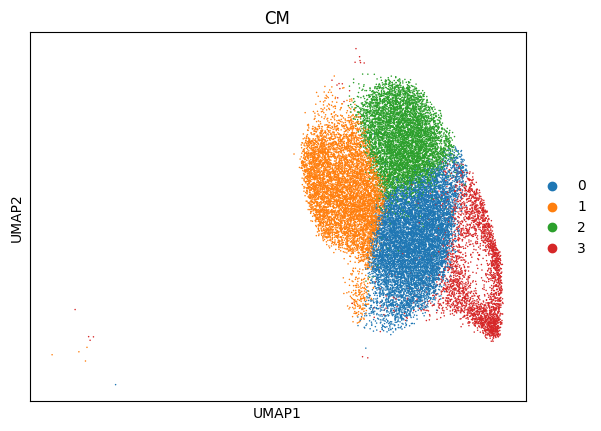

In [10]:
sc.pl.umap(adata, color="leiden", title=f"{ct}")

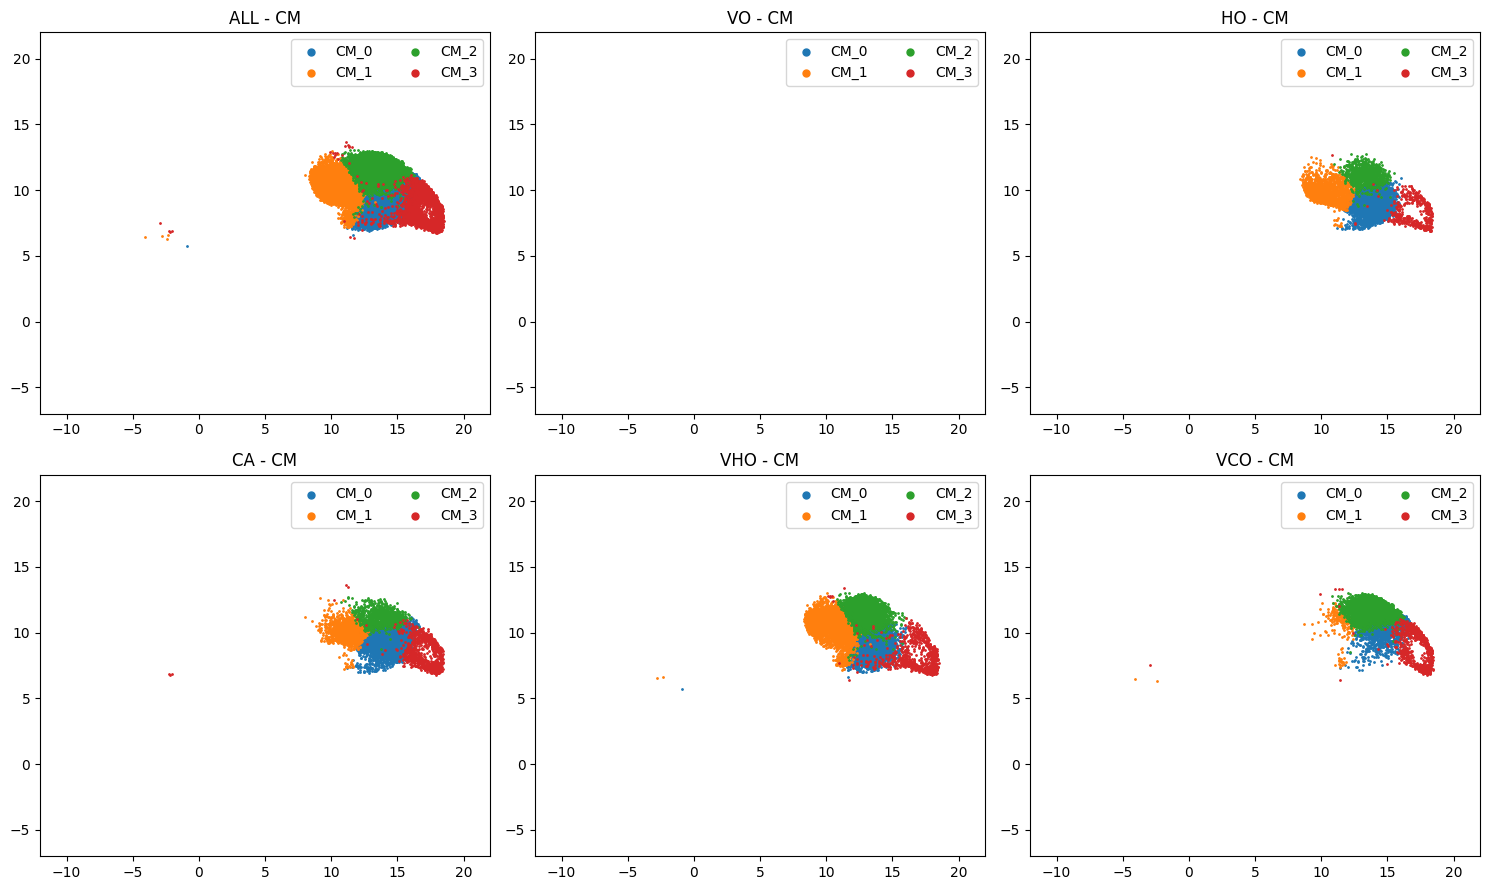

In [11]:
fig, axs = plt.subplots(2, 3, figsize=(15,9))
axs = axs.flatten()

for j, sample in enumerate(samples):
    
    ax = axs[j]
    
    if sample == 'ALL':
        adata_sample = adata
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        
    for i in range(0, len(adata.obs['leiden'].unique())):
        adata_sub = adata_sample[adata_sample.obs['leiden'] == str(i)]
        ax.scatter(adata_sub.obsm['X_umap'][:, 0], adata_sub.obsm['X_umap'][:, 1], label=f"{ct}_{i}", s=1)
    
    ax.set_xlim([-12, 22])
    ax.set_ylim([-7, 22])
    ax.legend(loc='upper right', markerscale=5, ncol=2)
    ax.set_title(f"{sample} - {ct}")
    
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/umaps/subclusters_{ct}.png')
plt.show()

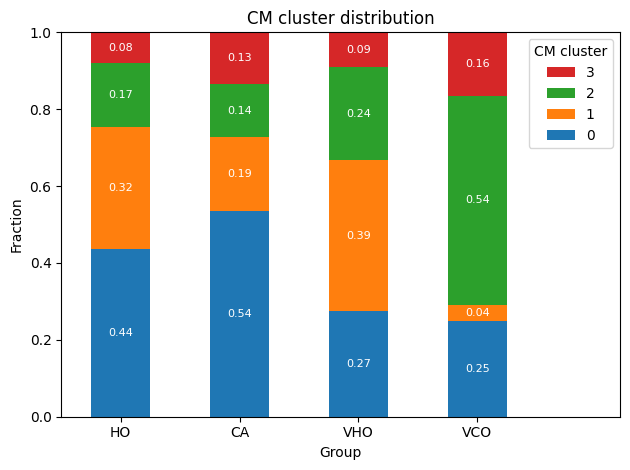

In [12]:
res = []
res_col = []

for j, sample in enumerate(samples):    
    if sample == 'ALL' or sample == 'VO':
        continue
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        res.append(adata_sample.obs['leiden'].value_counts())
        res_col.append(sample)
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df = np.divide(df, df.sum())
df = df.T

ax = df.plot(kind='bar', stacked=True)
plt.xlabel('Group')
plt.ylabel('Fraction')
plt.ylim((0, 1))
plt.xlim((-0.5, 4.2))
plt.xticks(rotation=0)
plt.title(f"{ct} cluster distribution")

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title=f'{ct} cluster')

# Add fraction labels
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        if height > 0.01:  # Avoid cluttering small segments
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + height / 2,
                f'{height:.2f}',
                ha='center', va='center', fontsize=8, color='white'
            )

plt.tight_layout()
plt.show()

In [13]:
adata.obs['cell_type_subcluster'] = adata.obs['leiden'].copy()
adata.obs['cell_type_subcluster'] = ct + "_" + adata.obs['cell_type_subcluster'].astype('str')
adata.obs['cell_type_subcluster'] = adata.obs['cell_type_subcluster'].astype('category')

adata.obs["cpdb_group"] = adata.obs['cell_type_subcluster'].copy()
adata.obs["cpdb_group"] = adata.obs["cpdb_group"].map({'CM_0': 'CM', 'CM_1': 'CM', 'CM_2': 'CM', 'CM_3': 'CM'})
adata.obs["cpdb_group"] = adata.obs["cpdb_group"].astype('category')

adata.write_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")

## 2.2 Endothelial

In [14]:
ct = "EN"
adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_split/{ct}.h5ad")
sc.tl.leiden(adata, resolution=0.3, random_state=42)

adata.obs['leiden'] = adata.obs['leiden'].astype("int")
old_leiden = adata.obs['leiden'].unique()
old_leiden.sort()
for i, l in enumerate(old_leiden):
    adata.obs['leiden'].loc[adata.obs['leiden'] == l] = i
adata.obs['leiden'] = adata.obs['leiden'].astype("str")
adata.obs['leiden'] = adata.obs['leiden'].astype("category")
adata.obs['leiden']

/tmp/ipykernel_3752030/2993360462.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata.obs['leiden'].loc[adata.obs['leiden'] == l] = i


AAACCCACATCCTTGC-1-0    2
AAAGAACAGGGCAATC-1-0    2
AAAGGATGTCAAGCGA-1-0    2
AAAGGGCCAGCGTATT-1-0    0
AAATGGAAGCTGCCAC-1-0    1
                       ..
TTAGGCAGTGTGTCGC-1-4    2
TTCGCTGCAAGTGGGT-1-4    2
TTTACTGGTAGACACG-1-4    2
TTTCAGTAGCGCTGAA-1-4    2
TTTGATCAGCGCACAA-1-4    2
Name: leiden, Length: 4160, dtype: category
Categories (3, object): ['0', '1', '2']

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


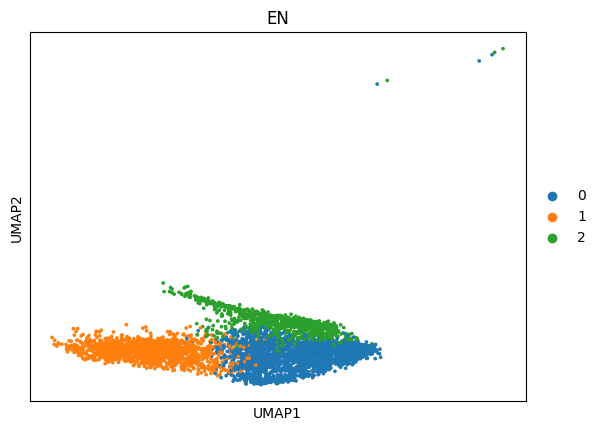

In [15]:
sc.pl.umap(adata, color="leiden", title=f"{ct}")

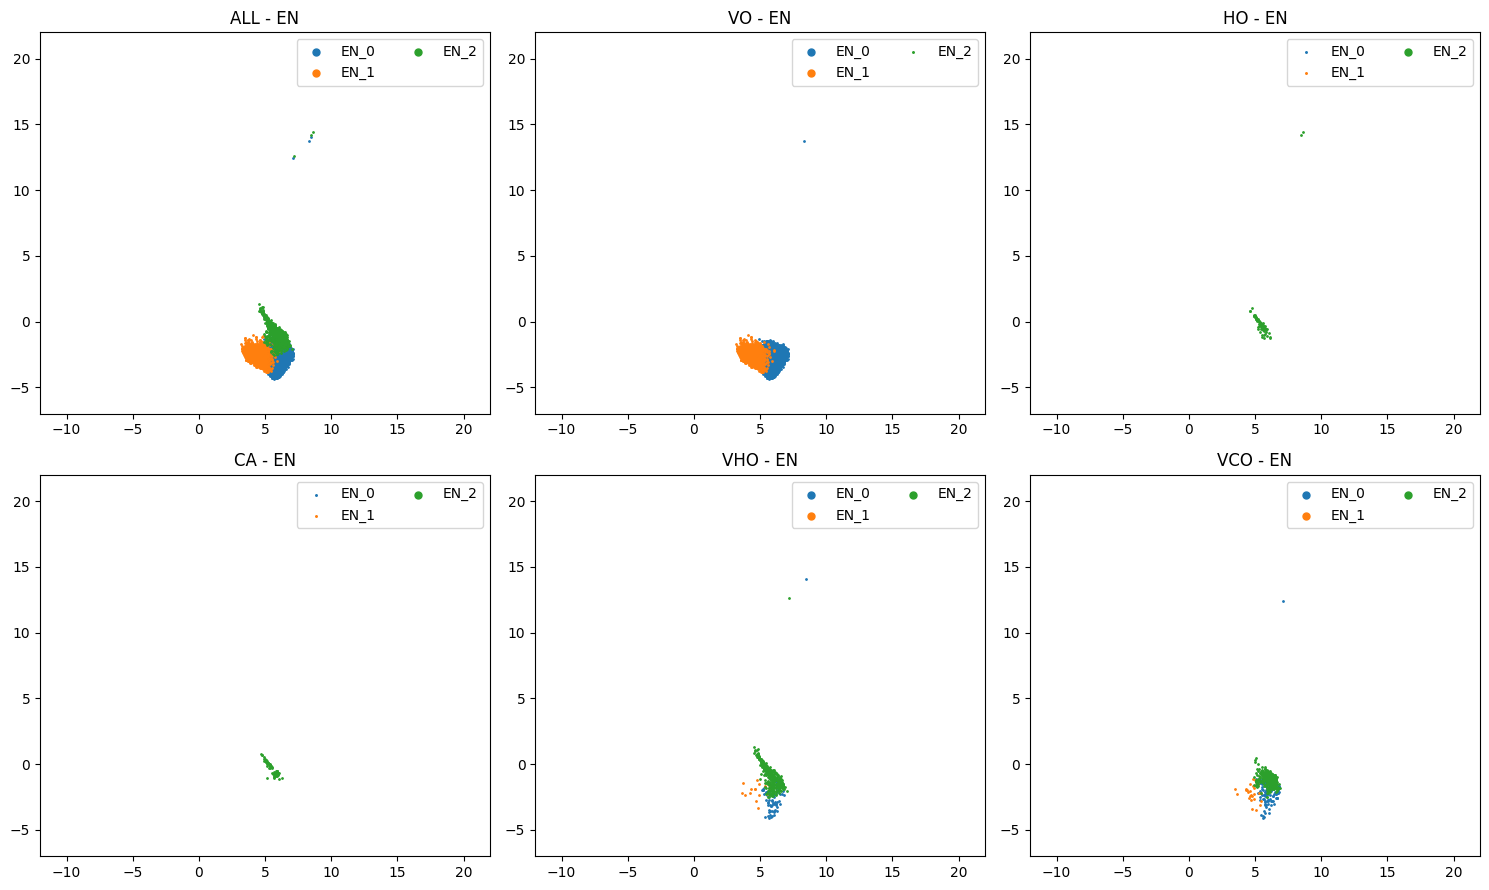

In [16]:
fig, axs = plt.subplots(2, 3, figsize=(15,9))
axs = axs.flatten()

for j, sample in enumerate(samples):
    
    ax = axs[j]
    
    if sample == 'ALL':
        adata_sample = adata
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        
    for i in range(0, len(adata.obs['leiden'].unique())):
        adata_sub = adata_sample[adata_sample.obs['leiden'] == str(i)]
        if len(adata_sub) < MIN_CELL_COUNT:
            ax.scatter(None, None, label=f"{ct}_{i}", s=0.05)
        else:
            ax.scatter(adata_sub.obsm['X_umap'][:, 0], adata_sub.obsm['X_umap'][:, 1], label=f"{ct}_{i}", s=1)
    
    ax.set_xlim([-12, 22])
    ax.set_ylim([-7, 22])
    ax.legend(loc='upper right', markerscale=5, ncol=2)
    ax.set_title(f"{sample} - {ct}")
    
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/umaps/subclusters_{ct}.png')
plt.show()

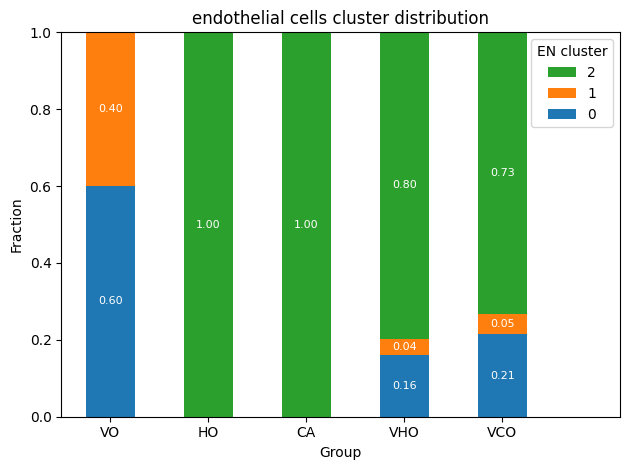

In [17]:
res = []
res_col = []

for j, sample in enumerate(samples):    
    if sample == 'ALL':
        continue
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        res.append(adata_sample.obs['leiden'].value_counts())
        res_col.append(sample)
        
for r in res:
    r[r < MIN_CELL_COUNT] = 0
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df = np.divide(df, df.sum())
df = df.T

ax = df.plot(kind='bar', stacked=True)
plt.xlabel('Group')
plt.ylabel('Fraction')
plt.ylim((0, 1))
plt.xlim((-0.5, 5.2))
plt.xticks(rotation=0)
plt.title("endothelial cells cluster distribution")

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title='EN cluster')

# Add fraction labels
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        if height > 0.01:  # Avoid cluttering small segments
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + height / 2,
                f'{height:.2f}',
                ha='center', va='center', fontsize=8, color='white'
            )

plt.tight_layout()
plt.show()

In [18]:
adata.obs['cell_type_subcluster'] = adata.obs['leiden'].copy()
adata.obs['cell_type_subcluster'] = ct + "_" + adata.obs['cell_type_subcluster'].astype('str')
adata.obs["cell_type_subcluster"] = adata.obs["cell_type_subcluster"].map({'EN_0': 'EN_V', 'EN_1': 'EN_V', 'EN_2': 'EN_H'})
adata.obs['cell_type_subcluster'] = adata.obs['cell_type_subcluster'].astype('category')

adata.obs["cpdb_group"] = adata.obs['cell_type_subcluster'].copy()
# adata.obs["cpdb_group"] = adata.obs["cpdb_group"].map({'EN_0': 'EN_V', 'EN_1': 'EN_V', 'EN_2': 'EN_H'})
adata.obs["cpdb_group"] = adata.obs["cpdb_group"].astype('category')

adata.write_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")

## 2.3 Fibroblast - ON HOLD

In [12]:
ct = "FB"
adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_split/{ct}.h5ad")
sc.tl.leiden(adata, resolution=0.5, random_state=42)

adata.obs['leiden'] = adata.obs['leiden'].astype("int")
old_leiden = adata.obs['leiden'].unique()
old_leiden.sort()
for i, l in enumerate(old_leiden):
    adata.obs['leiden'].loc[adata.obs['leiden'] == l] = i
adata.obs['leiden'] = adata.obs['leiden'].astype("str")
adata.obs['leiden'] = adata.obs['leiden'].astype("category")
adata.obs['leiden']

/tmp/ipykernel_3480338/656280993.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata.obs['leiden'].loc[adata.obs['leiden'] == l] = i


AAACCCATCATTGCGA-1-0    1
AAAGGATAGCGCCTAC-1-0    1
AAAGGGCTCTCGGTAA-1-0    2
AAAGGTAGTCCACAGC-1-0    3
AAAGTGATCTCATAGG-1-0    0
                       ..
CAGGGCTCAAGCACAG-1-4    1
CCTCATGGTCTGTGGC-1-4    2
CGCATAATCATTGCCC-1-4    3
CTCCTCCAGTCCTGTA-1-4    2
TCTACATAGGTTATAG-1-4    2
Name: leiden, Length: 9737, dtype: category
Categories (5, object): ['0', '1', '2', '3', '4']

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


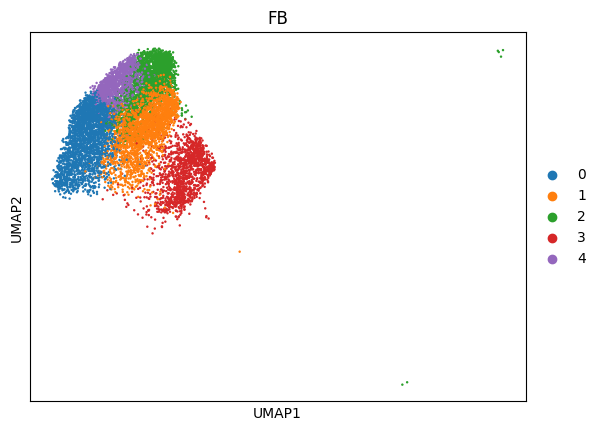

In [13]:
sc.pl.umap(adata, color="leiden", title=f"{ct}")

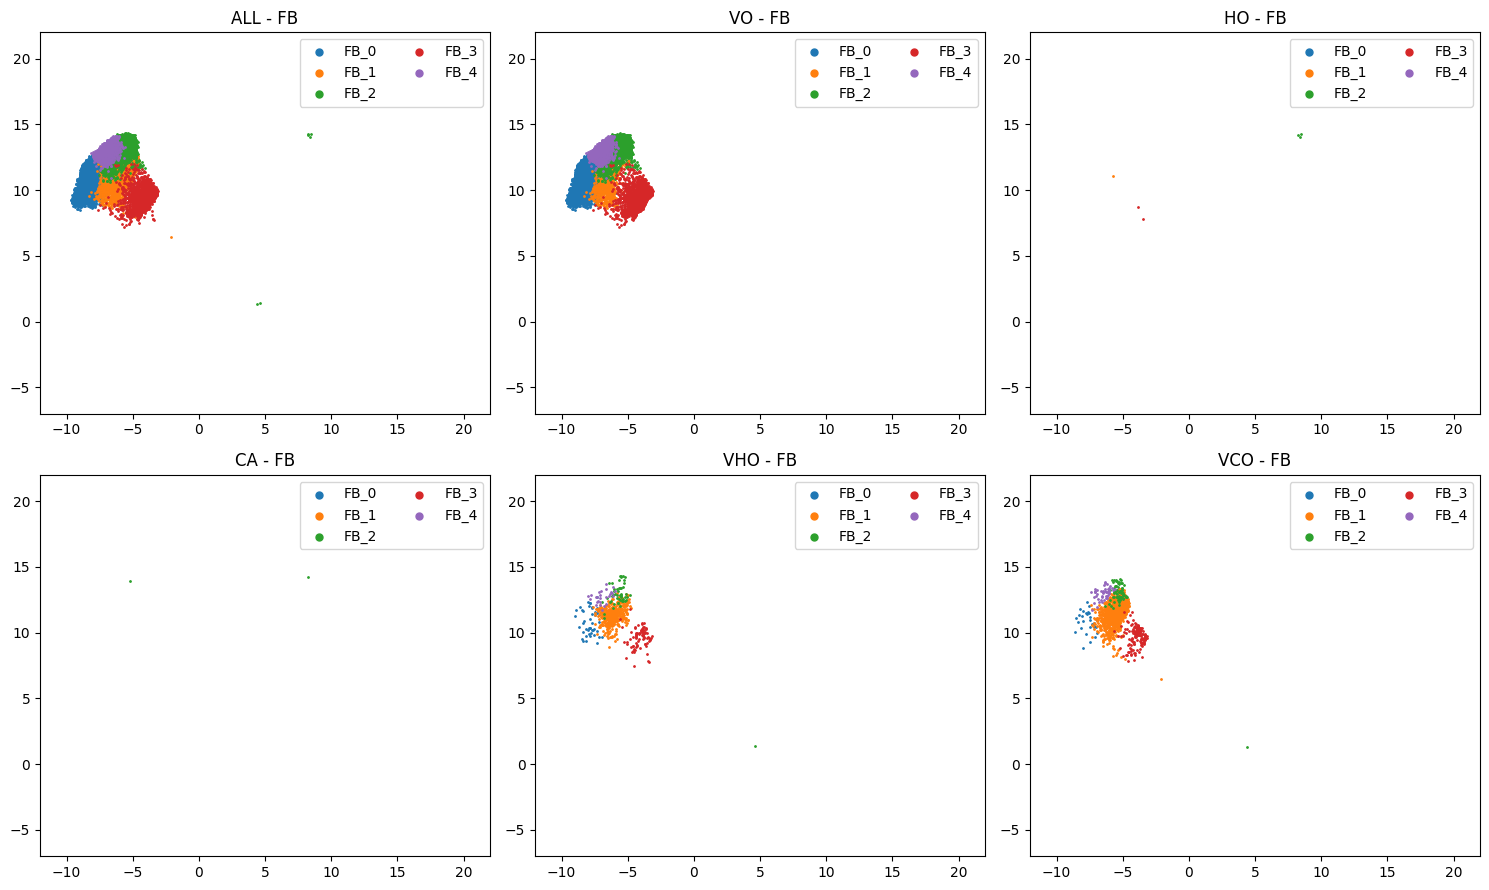

In [14]:
fig, axs = plt.subplots(2, 3, figsize=(15,9))
axs = axs.flatten()

for j, sample in enumerate(samples):
    
    ax = axs[j]
    
    if sample == 'ALL':
        adata_sample = adata
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        
    for i in range(0, len(adata.obs['leiden'].unique())):
        adata_sub = adata_sample[adata_sample.obs['leiden'] == str(i)]
        ax.scatter(adata_sub.obsm['X_umap'][:, 0], adata_sub.obsm['X_umap'][:, 1], label=f"{ct}_{i}", s=1)
    
    ax.set_xlim([-12, 22])
    ax.set_ylim([-7, 22])
    ax.legend(loc='upper right', markerscale=5, ncol=2)
    ax.set_title(f"{sample} - {ct}")
    
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/umaps/subclusters_{ct}.png')
plt.show()

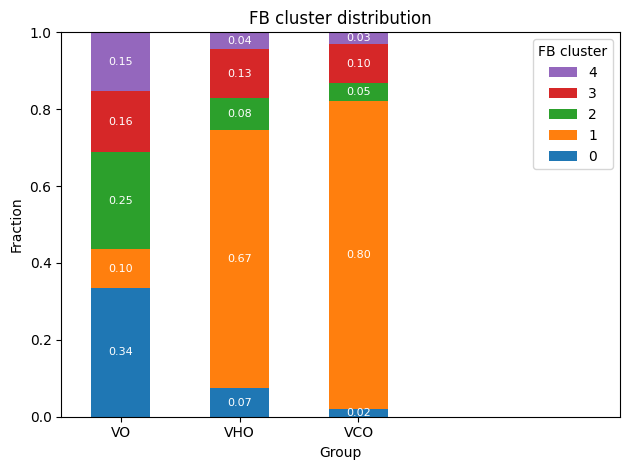

In [15]:
res = []
res_col = []

for j, sample in enumerate(samples):    
    if sample == 'ALL' or sample == 'HO' or sample == 'CA':
        continue
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        res.append(adata_sample.obs['leiden'].value_counts())
        res_col.append(sample)
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df = np.divide(df, df.sum())
df = df.T

ax = df.plot(kind='bar', stacked=True)
plt.xlabel('Group')
plt.ylabel('Fraction')
plt.ylim((0, 1))
plt.xlim((-0.5, 4.2))
plt.xticks(rotation=0)
plt.title(f"{ct} cluster distribution")

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title=f'{ct} cluster')

# Add fraction labels
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        if height > 0.01:  # Avoid cluttering small segments
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + height / 2,
                f'{height:.2f}',
                ha='center', va='center', fontsize=8, color='white'
            )

plt.tight_layout()
plt.show()

In [16]:
adata.obs['cell_type_subcluster'] = adata.obs['leiden'].copy()
adata.obs['cell_type_subcluster'] = ct + "_" + adata.obs['cell_type_subcluster'].astype('str')
adata.obs['cell_type_subcluster'] = adata.obs['cell_type_subcluster'].astype('category')
adata.write_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")

## 2.4 Smooth muscle cells - ON HOLD

In [17]:
ct = "SM"
adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_split/{ct}.h5ad")
sc.tl.leiden(adata, resolution=0.1, random_state=42)

adata.obs['leiden'] = adata.obs['leiden'].astype("int")
old_leiden = adata.obs['leiden'].unique()
old_leiden.sort()
for i, l in enumerate(old_leiden):
    adata.obs['leiden'].loc[adata.obs['leiden'] == l] = i
adata.obs['leiden'] = adata.obs['leiden'].astype("str")
adata.obs['leiden'] = adata.obs['leiden'].astype("category")
adata.obs['leiden']

/tmp/ipykernel_3480338/3814091195.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata.obs['leiden'].loc[adata.obs['leiden'] == l] = i


AAACGAAAGGTCGTCC-1-0    0
AAAGTCCCATTGTGCA-1-0    0
AAAGTGAAGGATACGC-1-0    0
AAGAACAAGAGATTCA-1-0    0
AAGAACAAGGTTCTAC-1-0    0
                       ..
TTGGGTATCAGTGATC-1-4    0
TTTACGTGTCCGGCAT-1-4    0
TTTCCTCAGTCCTGCG-1-4    0
TTTGACTGTGGTAACG-1-4    0
TTTGTTGCAGCACAAG-1-4    0
Name: leiden, Length: 1778, dtype: category
Categories (2, object): ['0', '1']

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


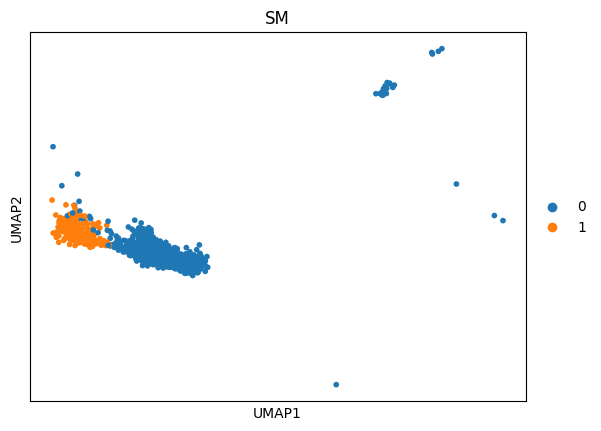

In [18]:
sc.pl.umap(adata, color="leiden", title=f"{ct}")

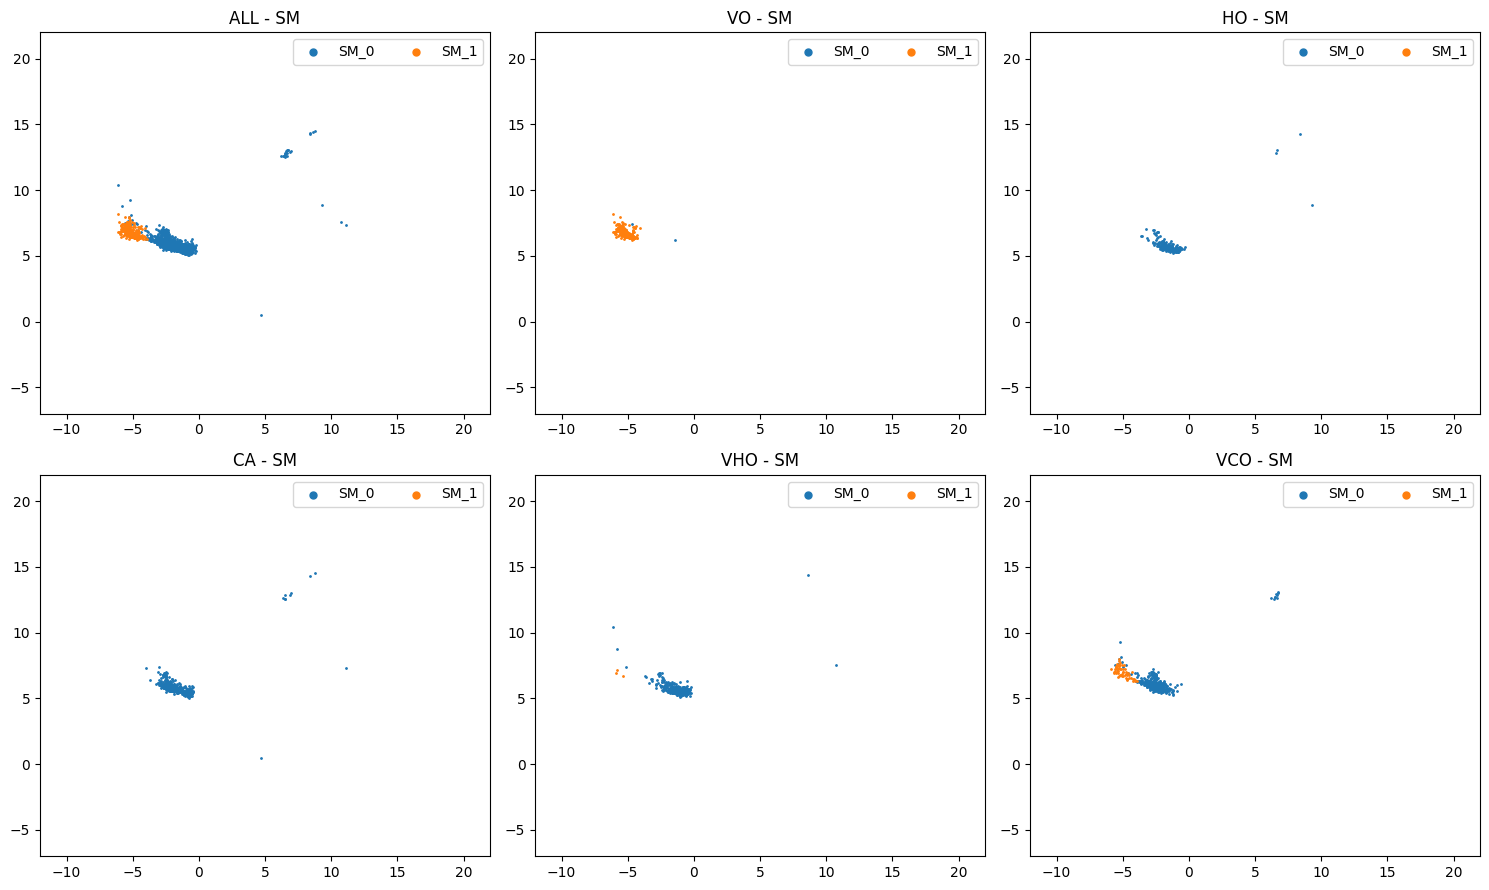

In [19]:
fig, axs = plt.subplots(2, 3, figsize=(15,9))
axs = axs.flatten()

for j, sample in enumerate(samples):
    
    ax = axs[j]
    
    if sample == 'ALL':
        adata_sample = adata
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        
    for i in range(0, len(adata.obs['leiden'].unique())):
        adata_sub = adata_sample[adata_sample.obs['leiden'] == str(i)]
        ax.scatter(adata_sub.obsm['X_umap'][:, 0], adata_sub.obsm['X_umap'][:, 1], label=f"{ct}_{i}", s=1)
    
    ax.set_xlim([-12, 22])
    ax.set_ylim([-7, 22])
    ax.legend(loc='upper right', markerscale=5, ncol=2)
    ax.set_title(f"{sample} - {ct}")
    
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/umaps/subclusters_{ct}.png')
plt.show()

In [20]:
adata.obs['cell_type_subcluster'] = adata.obs['leiden'].copy()
adata.obs['cell_type_subcluster'] = ct + "_" + adata.obs['cell_type_subcluster'].astype('str')
adata.obs['cell_type_subcluster'] = adata.obs['cell_type_subcluster'].astype('category')
adata.write_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")

## 2.5 TEMP: cluster mural cells

In [6]:
ct = "MU"
adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_split/{ct}.h5ad")
sc.tl.leiden(adata, resolution=1, random_state=42)

adata.obs['leiden'] = adata.obs['leiden'].astype("int")
old_leiden = adata.obs['leiden'].unique()
old_leiden.sort()
for i, l in enumerate(old_leiden):
    adata.obs['leiden'].loc[adata.obs['leiden'] == l] = i
adata.obs['leiden'] = adata.obs['leiden'].astype("str")
adata.obs['leiden'] = adata.obs['leiden'].astype("category")
adata.obs['leiden']

/tmp/ipykernel_3881866/3664054413.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata.obs['leiden'].loc[adata.obs['leiden'] == l] = i


AAACCCAAGTGGTCAG-1-0    3
AAACCCATCATTGCGA-1-0    5
AAACGAAAGAGCCGTA-1-0    2
AAACGAAAGGTCGTCC-1-0    8
AAAGAACAGCTCGCAC-1-0    3
                       ..
TTGGGTATCAGTGATC-1-4    8
TTTACGTGTCCGGCAT-1-4    8
TTTCCTCAGTCCTGCG-1-4    8
TTTGACTGTGGTAACG-1-4    8
TTTGTTGCAGCACAAG-1-4    8
Name: leiden, Length: 20095, dtype: category
Categories (10, object): ['0', '1', '2', '3', ..., '6', '7', '8', '9']

In [7]:
# ct = "MU"
# adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")

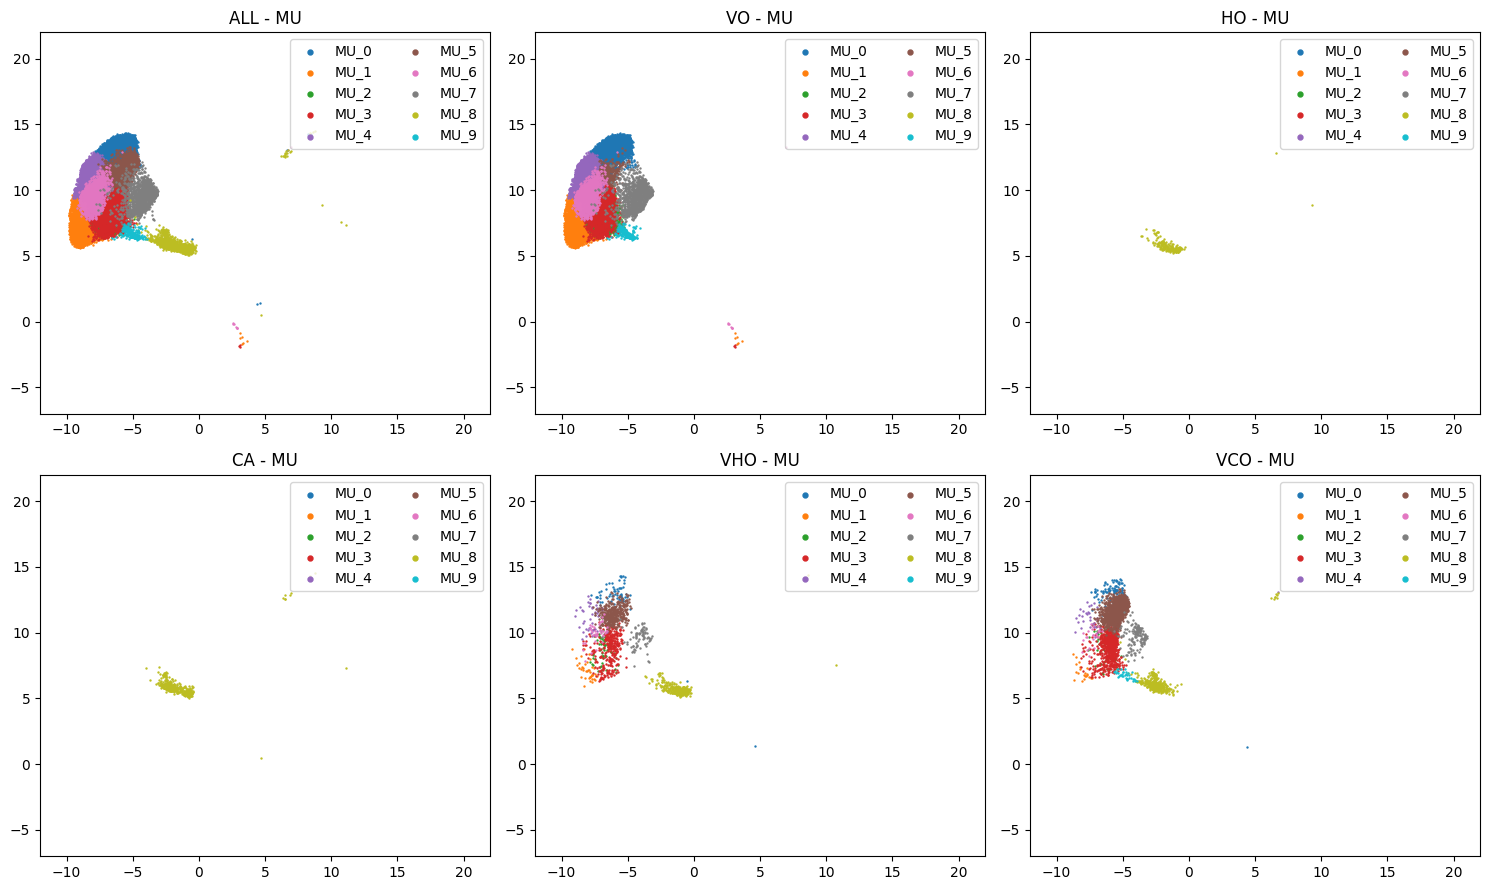

In [8]:
fig, axs = plt.subplots(2, 3, figsize=(15,9))
axs = axs.flatten()

for j, sample in enumerate(samples):
    
    ax = axs[j]
    
    if sample == 'ALL':
        adata_sample = adata
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        
    for i in range(0, len(adata.obs['leiden'].unique())):
        adata_sub = adata_sample[adata_sample.obs['leiden'] == str(i)]
        if len(adata_sub) < MIN_CELL_COUNT:
            ax.scatter(None, None, label=f"{ct}_{i}", s=0.5)
        else:
            ax.scatter(adata_sub.obsm['X_umap'][:, 0], adata_sub.obsm['X_umap'][:, 1], label=f"{ct}_{i}", s=0.5)
    
    ax.set_xlim([-12, 22])
    ax.set_ylim([-7, 22])
    ax.legend(loc='upper right', markerscale=5, ncol=2)
    ax.set_title(f"{sample} - {ct}")
    
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/umaps/subclusters_{ct}.png')
plt.show()

In [9]:
# marker_dict = ['CDH5', 'PECAM1', 'NOS3', 'VWF', 'CD34', 'ENG', 'FLT1', 'TEK', 'PDPN', 'MYH6', 
#                'MYH7', 'ACTC1', 'TNNT2', 'TNNI3', 'TNNI1', 'MYL2', 'MYL7', 'ACTA2', 'TAGLN', 'MYH11', 
#                'CNN1', 'DES', 'SMTN', 'VIM', 'CALD1', 'ELN', 'MYLK', 'S100A4', 'PDGFRA', 'THY1', 
#                'COL1A1', 'PDGFRB', 'CSPG4', 'RGS5', 'MCAM', 'NES', 'ITGB3', 'TGFBR1', 'TGFBR2', 'WT1', 
#                'TBX18', 'KRT8', 'KRT18', 'CDH1', 'EPCAM', 'SHH', 'RARA']

# sc.pl.dotplot(adata, marker_dict, groupby="cell_type_subcluster", standard_scale="var", swap_axes=True, title="FB + SM + PR")

In [10]:
# marker_dict = ['ACVRL1', 'KDR', 'TEK', 'ANGPT2', 'NOTCH1', 
#                'NOTCH2', 'NOTCH3', 'NOTCH4', 'NRG1', 'TGFB1', 
#                'ERBB4', 'EDN1', 'C7', 'FN1', 'PLXDC2', 'PTN', 
#                'RGS5', 'COL4A1', 'COL1A1', 'CXCL12', 'VEGFA']

# sc.pl.dotplot(adata, marker_dict, groupby="cell_type_subcluster", standard_scale="var", swap_axes=True, title="FB + SM + PR")

In [11]:
adata.obs['cell_type_subcluster'] = adata.obs['leiden'].copy()
adata.obs['cell_type_subcluster'] = ct + "_" + adata.obs['cell_type_subcluster'].astype('str')
adata.obs['cell_type_subcluster'] = adata.obs['cell_type_subcluster'].map(
    {'MU_0': 'FB_V', 
     'MU_1': 'PR', 
     'MU_2': 'PR', 
     'MU_3': 'PR', 
     'MU_4': 'FB_V', 
     'MU_5': 'FB_V', 
     'MU_6': 'FB_V', 
     'MU_7': 'FB_V', 
     'MU_8': 'FB_H', 
     'MU_9': 'SM',}
)
adata.obs['cell_type_subcluster'] = adata.obs['cell_type_subcluster'].astype('category')

adata.obs["cpdb_group"] = adata.obs['cell_type_subcluster'].copy()
# adata.obs["cpdb_group"] = adata.obs["cpdb_group"].map(
#     {'MU_0': 'FB_V', 
#      'MU_1': 'PR', 
#      'MU_2': 'PR', 
#      'MU_3': 'PR', 
#      'MU_4': 'FB_V', 
#      'MU_5': 'FB_V', 
#      'MU_6': 'FB_V', 
#      'MU_7': 'FB_V', 
#      'MU_8': 'FB_H', 
#      'MU_9': 'SM_V',}
# )
adata.obs["cpdb_group"] = adata.obs["cpdb_group"].astype('category')

adata.write_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")

In [12]:
adata.obs['cell_type_subcluster'].unique()

['PR', 'FB_V', 'FB_H', 'SM']
Categories (4, object): ['FB_H', 'FB_V', 'PR', 'SM']

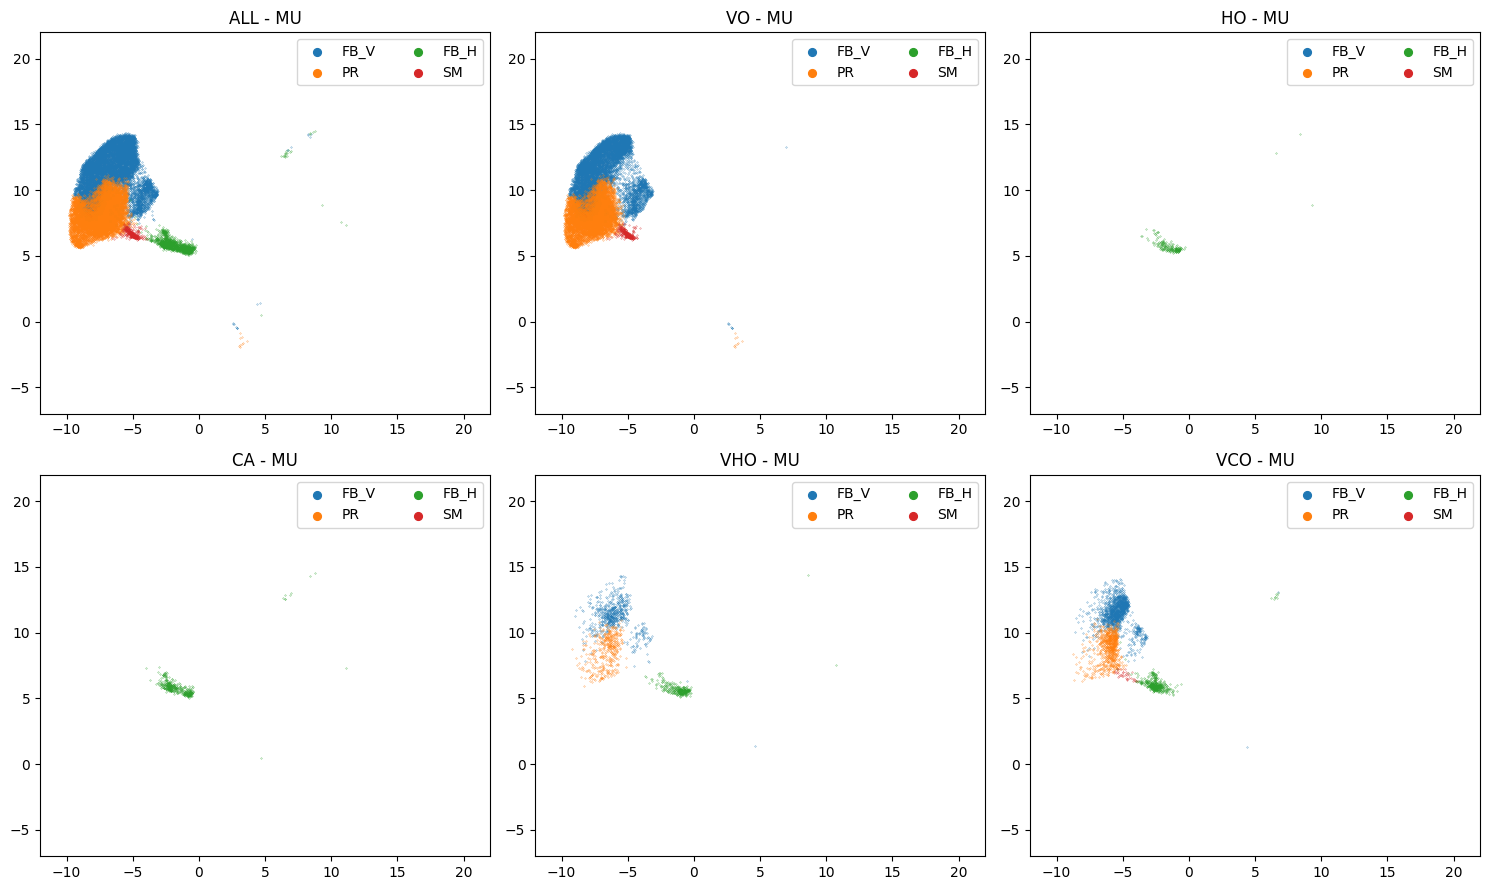

In [13]:
fig, axs = plt.subplots(2, 3, figsize=(15,9))
axs = axs.flatten()

for j, sample in enumerate(samples):
    
    ax = axs[j]
    
    if sample == 'ALL':
        adata_sample = adata
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        
    # for i, cpdb_g in enumerate(adata.obs['cell_type_subcluster'].unique()):
    for i, cpdb_g in enumerate(['FB_V', 'PR', 'FB_H', 'SM']):
        adata_sub = adata_sample[adata_sample.obs['cell_type_subcluster'] == cpdb_g]
        if len(adata_sub) < MIN_CELL_COUNT:
            ax.scatter(None, None, label=cpdb_g, s=0.05)
        else:
            ax.scatter(adata_sub.obsm['X_umap'][:, 0], adata_sub.obsm['X_umap'][:, 1], label=cpdb_g, s=0.05)
    
    ax.set_xlim([-12, 22])
    ax.set_ylim([-7, 22])
    ax.legend(loc='upper right', markerscale=25, ncol=2)
    ax.set_title(f"{sample} - {ct}")
    
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/umaps/subclusters_{ct}_labelled.png')
plt.show()

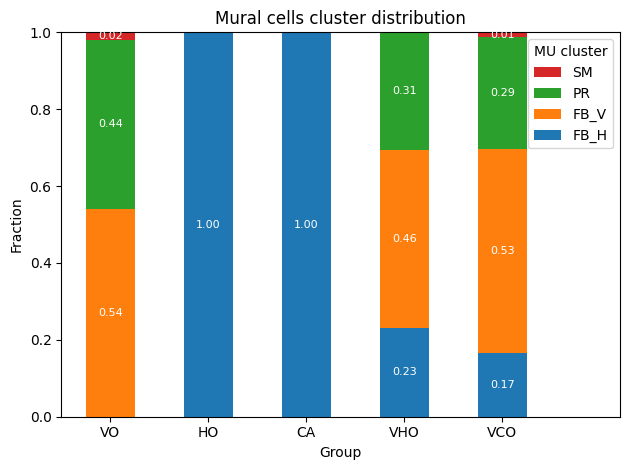

In [14]:
res = []
res_col = []

for j, sample in enumerate(samples):    
    if sample == 'ALL':
        continue
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        res.append(adata_sample.obs['cell_type_subcluster'].value_counts())
        res_col.append(sample)
        
for r in res:
    r[r < MIN_CELL_COUNT] = 0
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df = np.divide(df, df.sum())
df = df.T

ax = df.plot(kind='bar', stacked=True)
plt.xlabel('Group')
plt.ylabel('Fraction')
plt.ylim((0, 1))
plt.xlim((-0.5, 5.2))
plt.xticks(rotation=0)
plt.title("Mural cells cluster distribution")

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title='MU cluster')

# Add fraction labels
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        if height > 0.01:  # Avoid cluttering small segments
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + height / 2,
                f'{height:.2f}',
                ha='center', va='center', fontsize=8, color='white'
            )

plt.tight_layout()
plt.show()

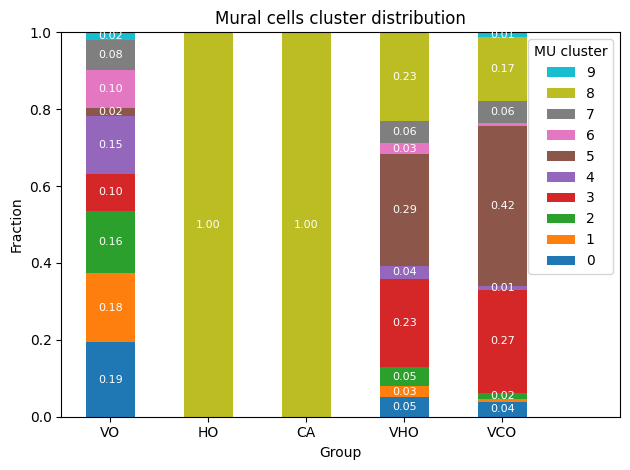

In [15]:
res = []
res_col = []

for j, sample in enumerate(samples):    
    if sample == 'ALL':
        continue
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        res.append(adata_sample.obs['leiden'].value_counts())
        res_col.append(sample)
        
for r in res:
    r[r < MIN_CELL_COUNT] = 0
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df = np.divide(df, df.sum())
df = df.T

ax = df.plot(kind='bar', stacked=True)
plt.xlabel('Group')
plt.ylabel('Fraction')
plt.ylim((0, 1))
plt.xlim((-0.5, 5.2))
plt.xticks(rotation=0)
plt.title("Mural cells cluster distribution")

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title='MU cluster')

# Add fraction labels
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        if height > 0.01:  # Avoid cluttering small segments
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + height / 2,
                f'{height:.2f}',
                ha='center', va='center', fontsize=8, color='white'
            )

plt.tight_layout()
plt.show()

## 2.5 keep other cell types as they are

In [28]:
# cts = ['PR','EP','UN']
cts = ['EP','UN']

for ct in cts:
    adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_split/{ct}.h5ad")
    adata.obs['cell_type_subcluster'] = adata.obs['cell_type'].copy()
    adata.obs['cpdb_group'] = adata.obs['cell_type'].copy()
    adata.write_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")

## 2.6 recollect

In [41]:
%%bash
rm -r /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/adata/sample_recollect
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/adata/sample_recollect

In [43]:
cell_type_subcluster = []
cpdb_group = []

for sample in ['ALL','VO','HO','CA','VHO','VCO']:
    # for ct in ['CM','PR','FB','SM','EP','EN','UN']:
    adata_sample = None
    for ct in ['CM','EN','MU','EP','UN']:
        
        adata_ct = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")
        
        if sample == 'ALL':
            adata_ct_sample = adata_ct
            cell_type_subcluster = cell_type_subcluster + adata_ct.obs['cell_type_subcluster'].unique().to_list()
            cell_type_subcluster.sort()
            cpdb_group = cpdb_group + adata_ct.obs['cpdb_group'].unique().to_list()
            cpdb_group.sort()
        else:
            adata_ct_sample = adata_ct[adata_ct.obs['batch'] == sample]
            
        group_counts = adata_ct_sample.obs["cpdb_group"].value_counts()
        valid_groups = group_counts[group_counts >= MIN_CELL_COUNT].index
        adata_ct_sample_filtered = adata_ct_sample[adata_ct_sample.obs["cpdb_group"].isin(valid_groups)].copy()

        if adata_sample is None:
            adata_sample = adata_ct_sample_filtered
        else:
            adata_sample = ad.concat([adata_sample, adata_ct_sample_filtered], join='inner', axis=0)
            
    adata_sample.write_h5ad(f"{WORK_DIR}/adata/sample_recollect/{sample}.h5ad")

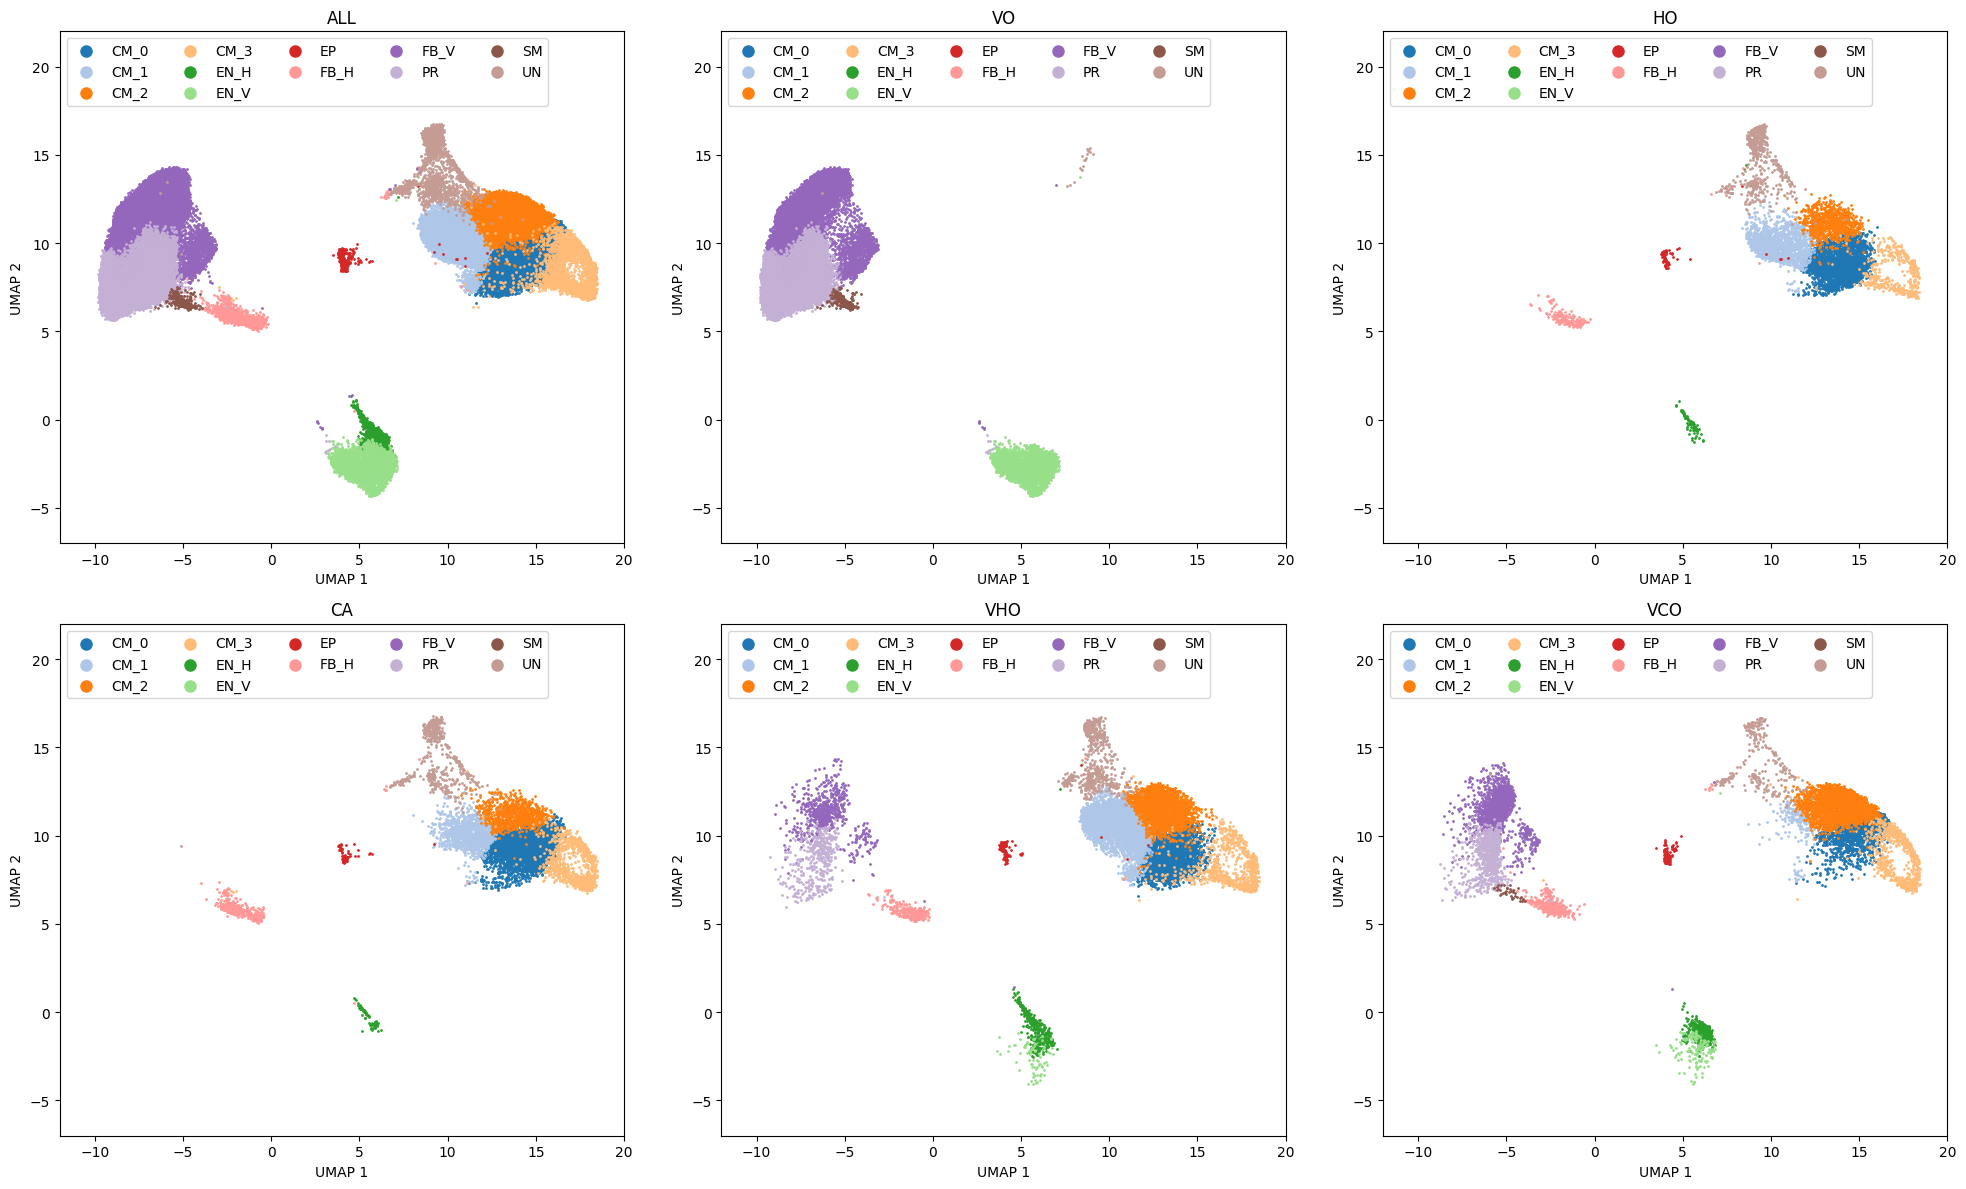

In [47]:
fig, axs = plt.subplots(2, 3, figsize=(20,12))
axs = axs.flatten()

cmap = plt.get_cmap('viridis')
colors = plt.get_cmap('tab20').colors

batch_mapper = dict(zip(samples_old, samples))

for i, sample in enumerate(samples):
    
    adata = sc.read_h5ad(f'{WORK_DIR}/adata/sample_recollect/{sample}.h5ad')
    
    for j, cts in enumerate(cell_type_subcluster):
        axs[i].scatter(
            adata.obsm['X_umap'][adata.obs['cell_type_subcluster'] == cts, 0], 
            adata.obsm['X_umap'][adata.obs['cell_type_subcluster'] == cts, 1], 
            label=cts, 
            color=colors[j], s=1)
        
    axs[i].legend(loc='upper left', markerscale=8, ncol=5)
    axs[i].set_xlabel('UMAP 1')
    axs[i].set_ylabel('UMAP 2')
    axs[i].set_title(sample)
    axs[i].set_xlim([-12, 20])
    axs[i].set_ylim([-7, 22])
    
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/umaps/sample_recollect.png')
plt.show()

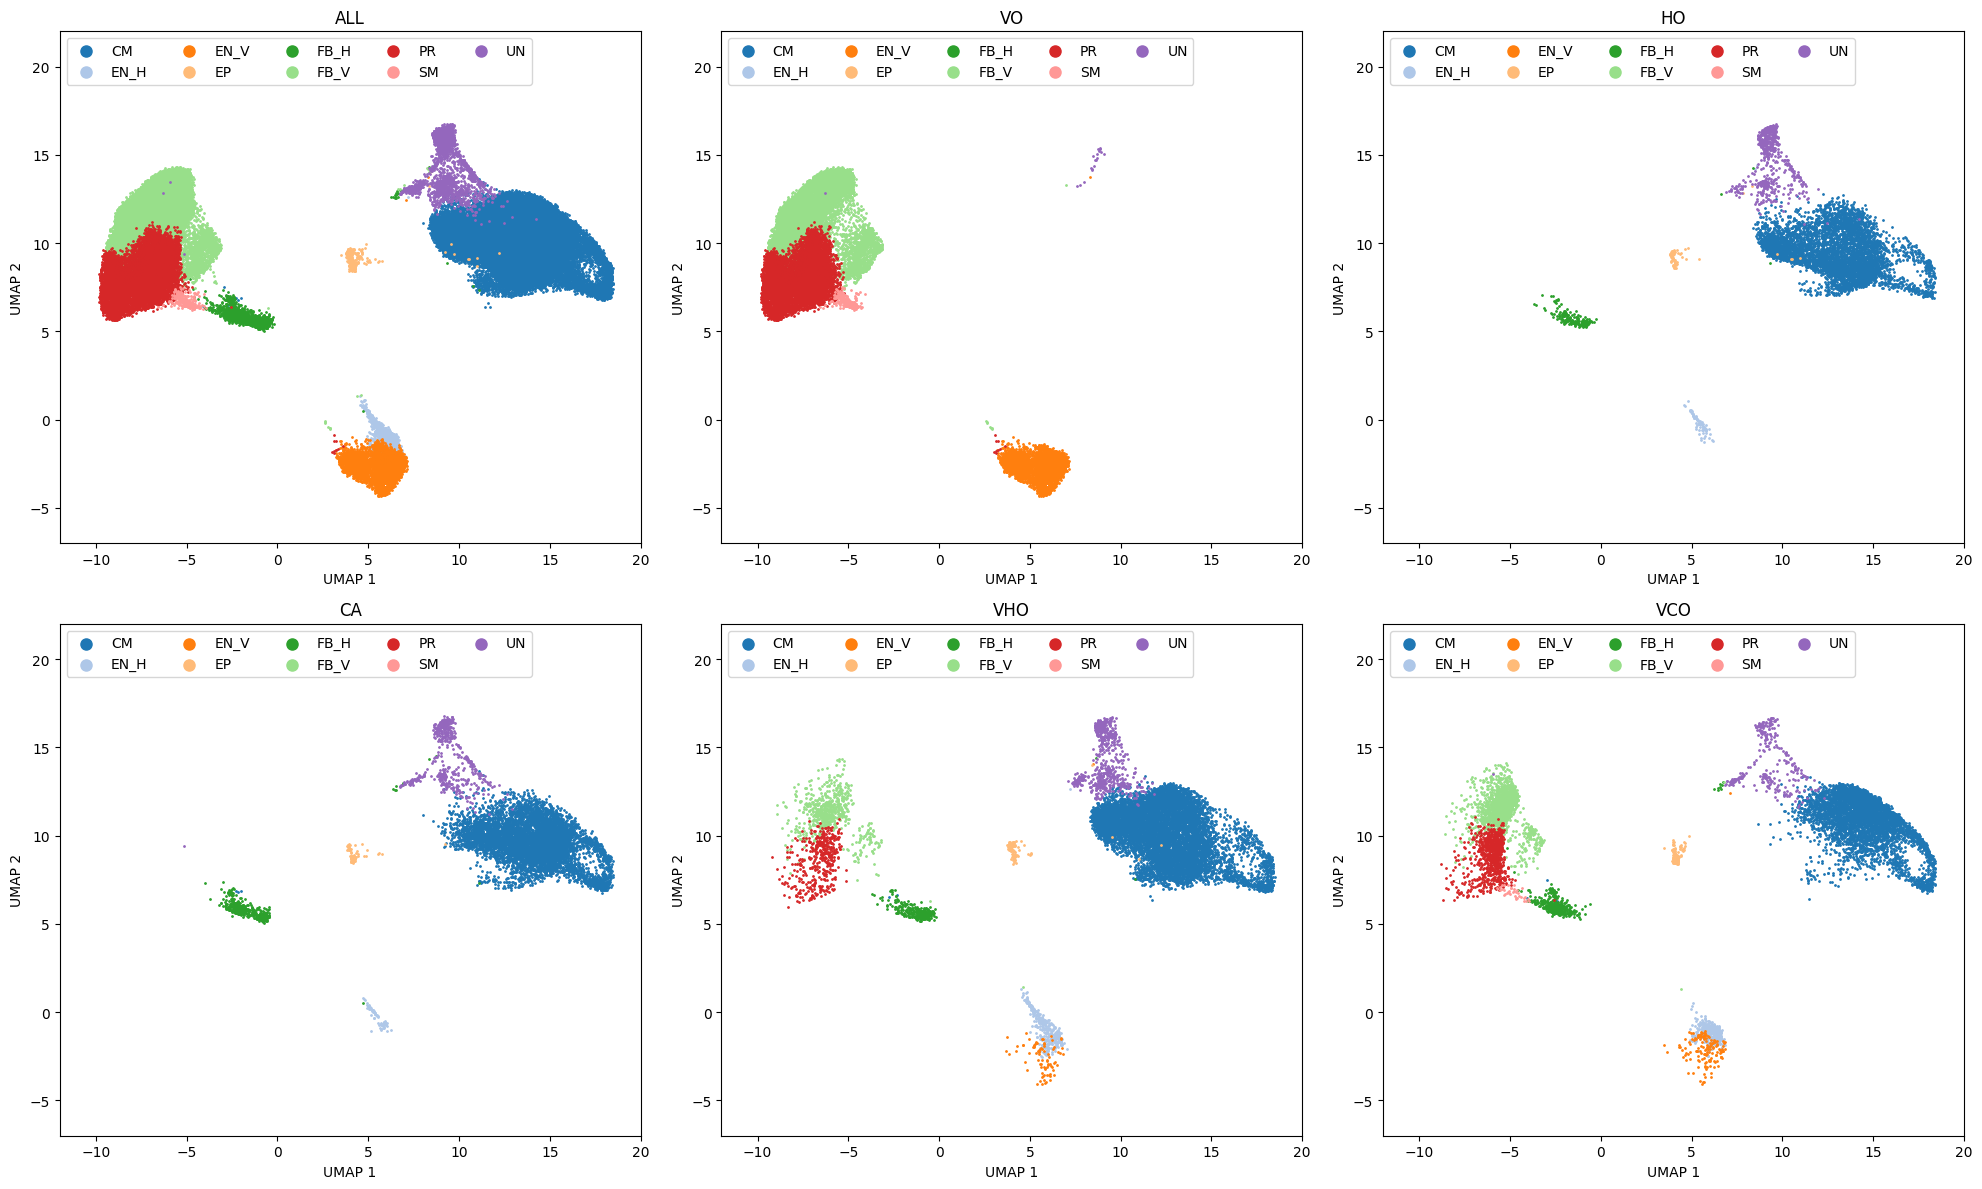

In [48]:
fig, axs = plt.subplots(2, 3, figsize=(20,12))
axs = axs.flatten()

cmap = plt.get_cmap('viridis')
colors = plt.get_cmap('tab20').colors

batch_mapper = dict(zip(samples_old, samples))

for i, sample in enumerate(samples):
    
    adata = sc.read_h5ad(f'{WORK_DIR}/adata/sample_recollect/{sample}.h5ad')
    
    for j, cts in enumerate(cpdb_group):
        axs[i].scatter(
            adata.obsm['X_umap'][adata.obs['cpdb_group'] == cts, 0], 
            adata.obsm['X_umap'][adata.obs['cpdb_group'] == cts, 1], 
            label=cts, 
            color=colors[j], s=1)
        
    axs[i].legend(loc='upper left', markerscale=8, ncol=5)
    axs[i].set_xlabel('UMAP 1')
    axs[i].set_ylabel('UMAP 2')
    axs[i].set_title(sample)
    axs[i].set_xlim([-12, 20])
    axs[i].set_ylim([-7, 22])
    
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/umaps/sample_recollect.cpdb.png')
plt.show()

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: N

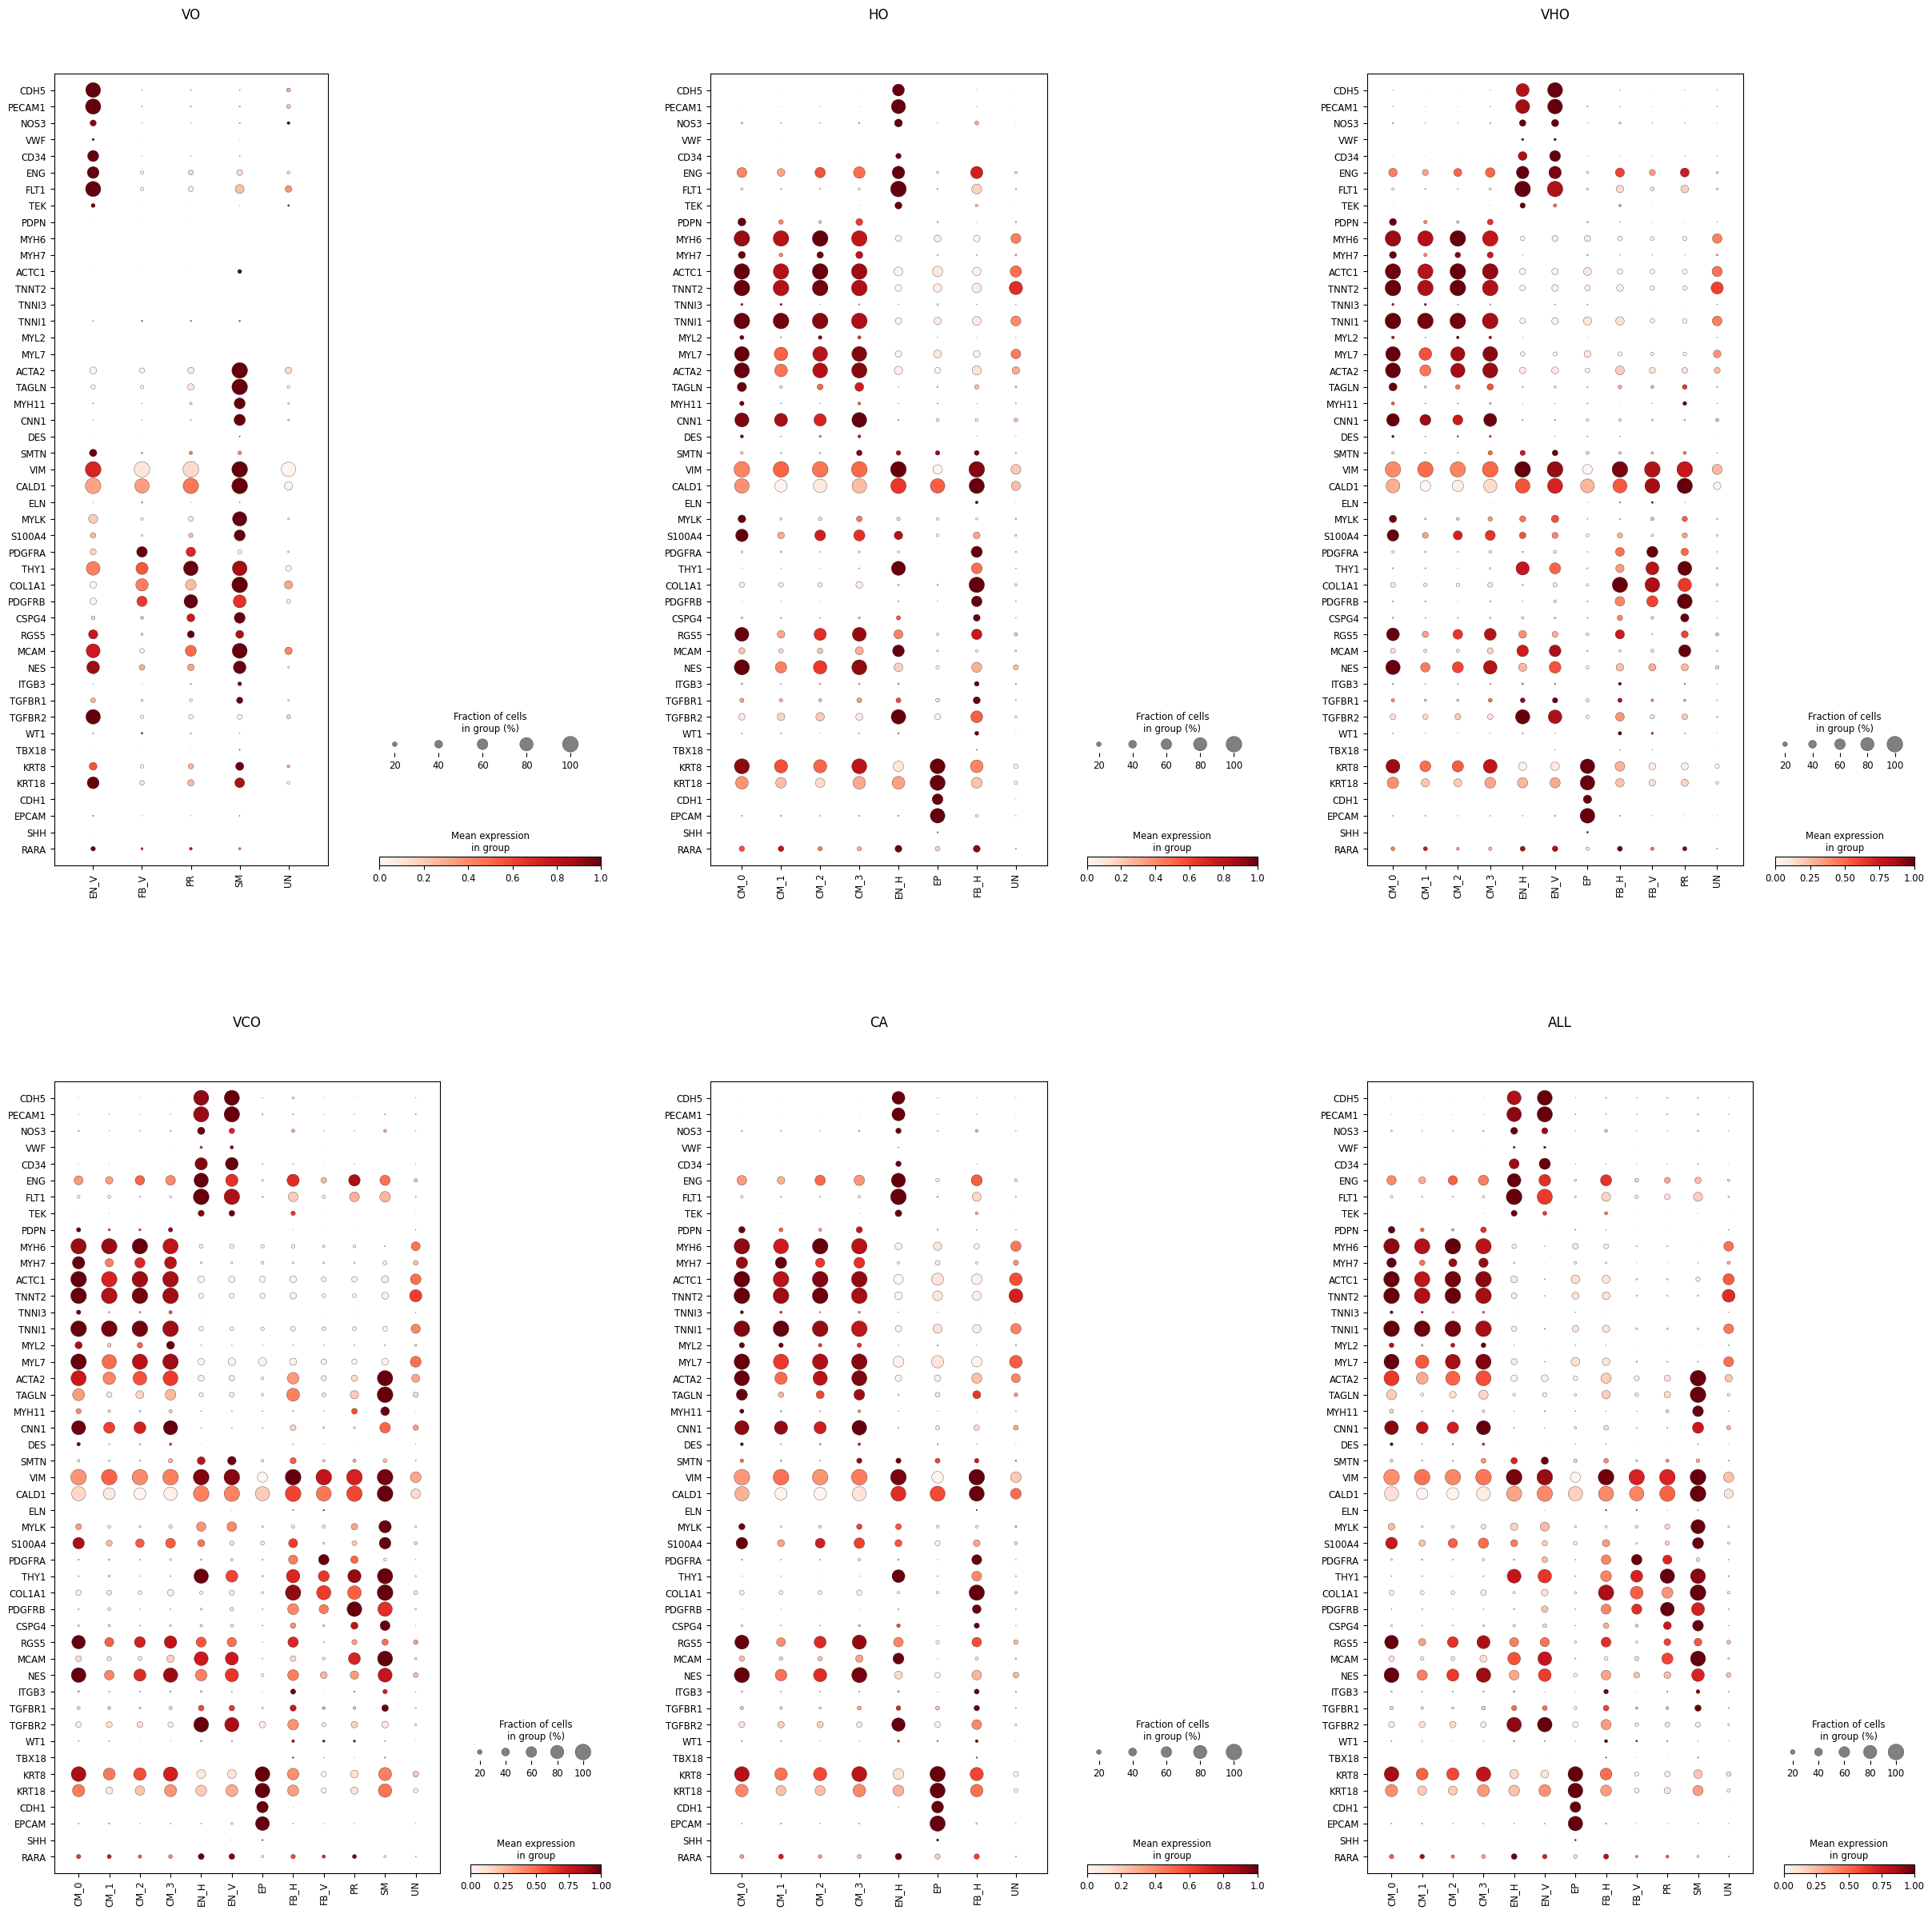

In [49]:
marker_dict = ['CDH5', 'PECAM1', 'NOS3', 'VWF', 'CD34', 'ENG', 'FLT1', 'TEK', 'PDPN', 'MYH6', 
               'MYH7', 'ACTC1', 'TNNT2', 'TNNI3', 'TNNI1', 'MYL2', 'MYL7', 'ACTA2', 'TAGLN', 'MYH11', 
               'CNN1', 'DES', 'SMTN', 'VIM', 'CALD1', 'ELN', 'MYLK', 'S100A4', 'PDGFRA', 'THY1', 
               'COL1A1', 'PDGFRB', 'CSPG4', 'RGS5', 'MCAM', 'NES', 'ITGB3', 'TGFBR1', 'TGFBR2', 'WT1', 
               'TBX18', 'KRT8', 'KRT18', 'CDH1', 'EPCAM', 'SHH', 'RARA']

fig, axs = plt.subplots(2, 3, figsize=(30,30), layout="constrained")
axs = axs.flatten()

for i, d1 in enumerate(glob.glob(f'{WORK_DIR}/adata/sample_recollect/*.h5ad')):
    sample_name = d1.split('/')[-1].strip('.h5ad')
    adata = sc.read_h5ad(d1)
    sc.pl.dotplot(adata, marker_dict, groupby="cell_type_subcluster", standard_scale="var", ax=axs[i], title=sample_name, show=False, swap_axes=True)
    
plt.savefig(f'{WORK_DIR}/dotplots/dotplot_celltype_subclusters.png')
plt.show()

# 3. DE within celltype between different subclusters

In [23]:
%%bash
rm -r /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/volcano/*
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/volcano/CM_subcluster
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/volcano/SM_subcluster
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/volcano/EN_subcluster
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/volcano/FB_subcluster

In [24]:
adata = sc.read_h5ad(f"{WORK_DIR}/adata/sample_recollect/ALL.h5ad")

In [25]:
def volcano_plot2(adata1, 
                  label1, 
                  label2, 
                  title, 
                  label_type='cell_type_subcluster', 
                  keygenes=None, 
                  save=None, 
                  save_tsv=None,
                  fc_thres=2, 
                  pvalue_thres=5):
    
    PSEUDOCOUNT=0.0001
    data1 = adata1.X[adata1.obs[label_type] == label1, :].todense().copy() + PSEUDOCOUNT
    data2 = adata1.X[adata1.obs[label_type] == label2, :].todense().copy() + PSEUDOCOUNT

    foldchanges = np.log2(
        np.divide(
            np.mean(data2,axis=0),
            np.mean(data1,axis=0)
        )
    )
    foldchanges = np.squeeze(np.asarray(foldchanges))

    means = np.mean(np.concatenate((data1, data2), axis=0), axis=0)
    s = np.squeeze(np.asarray(means)) ** 0.5
    s = s / s.mean() * 5

    ttest_results = scipy.stats.ttest_ind(
        data1,
        data2,
        axis=0,
        equal_var=False
    )
    pvalues = ttest_results[1]
    pvalues[pvalues == 0] = np.min(pvalues[pvalues > 0])
    transformed_pvalues = -1*np.log10(np.array(pvalues))

    idx_signi = [i for i in range(len(transformed_pvalues)) if transformed_pvalues[i] >= pvalue_thres]
    idx_inc = [i for i in idx_signi if foldchanges[i] > fc_thres]
    idx_dec = [i for i in idx_signi if foldchanges[i] < -1 * fc_thres]

    plt.scatter(foldchanges, 
                transformed_pvalues, 
                label='not significant',
                color='grey',
                alpha=0.5,
                s=s)
    plt.scatter(foldchanges[idx_inc], 
                transformed_pvalues[idx_inc], 
                label='up-regulated',
                color='red',
                alpha=0.5,
                s=s[idx_inc])
    plt.scatter(foldchanges[idx_dec], 
                transformed_pvalues[idx_dec], 
                label='down-regulated',
                color='blue',
                alpha=0.5,
                s=s[idx_dec])
    
    if keygenes is not None:
        for keygene in keygenes:
            gene_idx = adata1.var_names.tolist().index(keygene)
            plt.text(foldchanges[gene_idx], transformed_pvalues[gene_idx], keygene, ha='center', va='center')
            

    plt.xlabel('Log2FC')
    plt.ylabel('-log10 p-value')
    plt.title(title)
    plt.legend()
    if save is not None:
        plt.savefig(save)
        plt.close()
    else:
        plt.show()
    
    if save_tsv is not None:
        de_dict = {}
        de_dict['gene'] = adata1.var_names.to_list()
        de_dict['expression_1'] = np.squeeze(np.asarray(np.mean(data1, axis=0))) - PSEUDOCOUNT
        de_dict['expression_2'] = np.squeeze(np.asarray(np.mean(data2, axis=0))) - PSEUDOCOUNT
        de_dict['log2FC'] = foldchanges
        de_dict['-log10 p-val'] = transformed_pvalues
        de_dict['significant'] = [0 if (transformed_pvalues[i] < pvalue_thres or abs(foldchanges[i]) < fc_thres) else 1 for i in range(len(transformed_pvalues))]
        df = pd.DataFrame(de_dict)
        df.to_csv(save_tsv, sep='\t')
        df[df['significant'] == 1].to_csv(f"{(save_tsv).strip('.tsv')}.deg.tsv", sep='\t')

In [26]:
volcano_plot2(
    adata, 
    "EN_V", 
    "EN_H", 
    "EN_V vs. EN_H", 
    label_type="cpdb_group", 
    keygenes=None, 
    save=f"{WORK_DIR}/volcano/EN_subcluster/EN_V.EN_H.png", 
    save_tsv=f"{WORK_DIR}/volcano/EN_subcluster/EN_V.EN_H.tsv"
)

In [30]:
all_batches = ['VO', 'HO', 'VHO', 'CA', 'VCO']

for i in range(0, len(all_batches)):
    for j in range(i+1, len(all_batches)):
        batch1 = all_batches[i]
        batch2 = all_batches[j]
        volcano_plot2(
            adata[adata.obs["cell_type"] == "EN"], 
            batch1, 
            batch2, 
            f"EN: {batch1} vs {batch2}", 
            label_type="batch", 
            keygenes=None, 
            save=f"{WORK_DIR}/volcano/EN_subcluster/{batch1}.{batch2}.png", 
            save_tsv=f"{WORK_DIR}/volcano/EN_subcluster/{batch1}.{batch2}.tsv"
        )

/tmp/ipykernel_1585199/4222258570.py:28: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1585199/4222258570.py:28: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1585199/4222258570.py:28: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1585199/4222258570.py:28: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats

In [25]:
ct = "CM"

all_subclusters = list(adata[adata.obs['cell_type'] == ct].obs['cell_type_subcluster'].unique())

for i in range(0, len(all_subclusters)):
    for j in range(i+1, len(all_subclusters)):
        volcano_plot2(adata[adata.obs['cell_type'] == ct], 
                      all_subclusters[i], 
                      all_subclusters[j], 
                      f"{ct}.{i}.{j}.png", 
                      keygenes=None, 
                      save=f"{WORK_DIR}/volcano/{ct}_subcluster/{ct}.{i}.{j}.png", 
                      save_tsv=f"{WORK_DIR}/volcano/{ct}_subcluster/{ct}.{i}.{j}.tsv")

/tmp/ipykernel_3480338/905745284.py:22: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_3480338/905745284.py:22: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_3480338/905745284.py:22: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_3480338/905745284.py:22: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.tte

In [16]:
ct = "EN"

all_subclusters = list(adata[adata.obs['cell_type'] == ct].obs['cell_type_subcluster'].unique())

keygenes = ['ACVRL1', 'KDR', 'TEK', 'ANGPT2', 'NOTCH1', 
            'NOTCH2', 'NOTCH3', 'NOTCH4', 'NRG1', 'TGFB1', 
            'ERBB4', 'EDN1', 'C7', 'FN1', 'PLXDC2', 'PTN', 
            'RGS5', 'COL4A1', 'COL1A1', 'CXCL12', 'VEGFA']

for i in range(0, len(all_subclusters)):
    for j in range(i+1, len(all_subclusters)):
        volcano_plot2(adata[adata.obs['cell_type'] == ct], 
                      all_subclusters[i], 
                      all_subclusters[j], 
                      f"{ct}.{i}.{j}.png", 
                      keygenes=keygenes, 
                      save=f"{WORK_DIR}/volcano/{ct}_subcluster/{ct}.{i}.{j}.png", 
                      save_tsv=f"{WORK_DIR}/volcano/{ct}_subcluster/{ct}.{i}.{j}.tsv")

In [27]:
ct = "SM"

all_subclusters = list(adata[adata.obs['cell_type'] == ct].obs['cell_type_subcluster'].unique())

for i in range(0, len(all_subclusters)):
    for j in range(i+1, len(all_subclusters)):
        volcano_plot2(adata[adata.obs['cell_type'] == ct], 
                      all_subclusters[i], 
                      all_subclusters[j], 
                      f"{ct}.{i}.{j}.png", 
                      keygenes=None, 
                      save=f"{WORK_DIR}/volcano/{ct}_subcluster/{ct}.{i}.{j}.png", 
                      save_tsv=f"{WORK_DIR}/volcano/{ct}_subcluster/{ct}.{i}.{j}.tsv")

/tmp/ipykernel_3480338/905745284.py:22: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


In [28]:
ct = "FB"

all_subclusters = list(adata[adata.obs['cell_type'] == ct].obs['cell_type_subcluster'].unique())

keygenes = ['ACVRL1', 'KDR', 'TEK', 'ANGPT2', 'NOTCH1', 
            'NOTCH2', 'NOTCH3', 'NOTCH4', 'NRG1', 'TGFB1', 
            'ERBB4', 'EDN1', 'C7', 'FN1', 'PLXDC2', 'PTN', 
            'RGS5', 'COL4A1', 'COL1A1', 'CXCL12', 'VEGFA']
# keygenes = ['C7']

for i in range(0, len(all_subclusters)):
    for j in range(i+1, len(all_subclusters)):
        volcano_plot2(adata[adata.obs['cell_type'] == ct], 
                      all_subclusters[i], 
                      all_subclusters[j], 
                      f"{ct}.{i}.{j}.png", 
                      keygenes=keygenes, 
                      save=f"{WORK_DIR}/volcano/{ct}_subcluster/{ct}.{i}.{j}.png", 
                      save_tsv=f"{WORK_DIR}/volcano/{ct}_subcluster/{ct}.{i}.{j}.tsv")

/tmp/ipykernel_3480338/905745284.py:22: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_3480338/905745284.py:22: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_3480338/905745284.py:22: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_3480338/905745284.py:22: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.tte

# 4. Velocity

In [34]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/velocity
# cp /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/velocity/scVelo_job.* /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/velocity/

In [7]:
%%bash
# qsub /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/velocity/scVelo_job.sh

# 5. CellPhoneDB
 - switch to cellphonedb env

In [29]:
%%bash
rm -r /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/cpdb
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/cpdb
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/cpdb/processed
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/cpdb/adata
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/cpdb/figs

In [30]:
import os

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import ktplotspy as kpy
import seaborn as sns
import matplotlib.pyplot as plt

from glob import glob
from tqdm import tqdm

from cellphonedb.src.core.methods import cpdb_analysis_method,cpdb_statistical_analysis_method

In [31]:
data_dir  = "/home/herbert/PyProjects/cocultured_organ/workspace/CCO07/cpdb/adata"
work_dir  = "/home/herbert/PyProjects/cocultured_organ/workspace/CCO07/cpdb"
cpdb_path = "/home/brett/work/Cell2CellCommunication/cpdb/database/v5.0.0/cellphonedb.zip"
processed_dir = "/home/herbert/PyProjects/cocultured_organ/workspace/CCO07/cpdb/processed"
figs_dir = "/home/herbert/PyProjects/cocultured_organ/workspace/CCO07/cpdb/figs"

In [32]:
def normalize_c(value):
    if isinstance(value, str) and value.startswith('MU_'):
        return 'MU'
    return value

for adata_path in glob(f"/home/herbert/PyProjects/cocultured_organ/workspace/CCO07/adata/sample_recollect/*.h5ad"):
    basename = adata_path.split('/')[-1]
    adata = sc.read_h5ad(adata_path)
    sc.pp.highly_variable_genes(adata, n_top_genes=2000)
    # adata.obs['cell_type_subcluster'] = adata.obs['cell_type_subcluster'].apply(normalize_c)
    
    adata.write_h5ad(f"{data_dir}/{basename}")

In [33]:
# metadata_df['cell_type'].unique()

In [34]:
pattern = os.path.join(data_dir,"*.h5ad")
for adata_path in glob(pattern):
    if ("/HO.h5ad" not in adata_path) and ("/VCO.h5ad" not in adata_path):
        continue
    print(adata_path)

    label = os.path.basename(adata_path).split(".")[0]
    adata = sc.read_h5ad(adata_path)
    adata = adata[:,adata.var['highly_variable']]
    updated_adata_path = os.path.join(processed_dir,os.path.basename(adata_path.replace(".h5ad",".hvg.h5ad")))
    adata.write(updated_adata_path,compression="gzip")

    metadata_df = pd.DataFrame({
        "barcode_sample" : adata.obs_names,
        "cell_type"      : adata.obs['cpdb_group'].to_list()
    })

    metadata_df.index = np.arange(metadata_df.shape[0])
    metadata_path     = os.path.join(work_dir,f"{label}.statistical.metadata.tsv")
    metadata_df.to_csv(metadata_path,index=False,sep="\t")

    out_dir      = os.path.join(work_dir,f"{label}.statistical")
    # Threshold:0.1 Iterations:1000 Debug-seed:-1 Threads:4 Precision:3
    cpdb_results = cpdb_statistical_analysis_method.call(
        cpdb_file_path     = cpdb_path,         # mandatory: CellphoneDB database zip file.
        meta_file_path     = metadata_path,     # mandatory: tsv file defining barcodes to cell label.
        counts_file_path   = updated_adata_path,# mandatory: normalized count matrix - a path to the counts file, or an in-memory AnnData object
        counts_data        = 'gene_name',       # defines the gene annotation in counts matrix.
        score_interactions = True,              # optional: whether to score interactions or not. 
        output_path        = out_dir,           # Path to save results
    )

/home/herbert/PyProjects/cocultured_organ/workspace/CCO07/cpdb/adata/HO.h5ad
Reading user files...
The following user files were loaded successfully:
/home/herbert/PyProjects/cocultured_organ/workspace/CCO07/cpdb/processed/HO.hvg.h5ad
/home/herbert/PyProjects/cocultured_organ/workspace/CCO07/cpdb/HO.statistical.metadata.tsv
[ ][CORE][01/08/25-03:02:47][INFO] [Cluster Statistical Analysis] Threshold:0.1 Iterations:1000 Debug-seed:-1 Threads:4 Precision:3
[ ][CORE][01/08/25-03:02:47][INFO] Running Real Analysis
[ ][CORE][01/08/25-03:02:47][INFO] Running Statistical Analysis


100%|███████████████████████████████████████████████████████████| 1000/1000 [00:21<00:00, 47.50it/s]


[ ][CORE][01/08/25-03:03:08][INFO] Building Pvalues result
[ ][CORE][01/08/25-03:03:08][INFO] Building results
[ ][CORE][01/08/25-03:03:08][INFO] Scoring interactions: Filtering genes per cell type..


100%|████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 166.92it/s]

[ ][CORE][01/08/25-03:03:08][INFO] Scoring interactions: Calculating mean expression of each gene per group/cell type..


...

[ ][CORE][01/08/25-03:03:38][INFO] Scoring interactions: Calculating mean expression of each gene per group/cell type..



100%|████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 623.15it/s]


[ ][CORE][01/08/25-03:03:38][INFO] Scoring interactions: Calculating scores for all interactions and cell types..


100%|██████████████████████████████████████████████████████████████| 81/81 [00:00<00:00, 178.29it/s]


Saved deconvoluted to /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/cpdb/VCO.statistical/statistical_analysis_deconvoluted_08_01_2025_030339.txt
Saved deconvoluted_percents to /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/cpdb/VCO.statistical/statistical_analysis_deconvoluted_percents_08_01_2025_030339.txt
Saved means to /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/cpdb/VCO.statistical/statistical_analysis_means_08_01_2025_030339.txt
Saved pvalues to /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/cpdb/VCO.statistical/statistical_analysis_pvalues_08_01_2025_030339.txt
Saved significant_means to /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/cpdb/VCO.statistical/statistical_analysis_significant_means_08_01_2025_030339.txt
Saved interaction_scores to /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/cpdb/VCO.statistical/statistical_analysis_interaction_scores_08_01_2025_030339.txt


In [35]:
pattern = os.path.join(work_dir,"*.statistical")
date = "08_01_2025"
for cpdb_dir in glob(pattern):
    label = os.path.basename(cpdb_dir).replace(".statistical","")
    means_path         = glob(os.path.join(cpdb_dir,f"statistical_analysis_means_{date}_*.txt"))[0]
    pvals_path         = glob(os.path.join(cpdb_dir,f"statistical_analysis_pvalues_{date}_*.txt"))[0]
    deconvolution_path = glob(os.path.join(cpdb_dir,f"statistical_analysis_deconvoluted_{date}_*.txt"))[0]
    interaction_path   = glob(os.path.join(cpdb_dir,f"statistical_analysis_interaction_scores_{date}_*.txt"))[0]

    means_df         = pd.read_csv(means_path,sep="\t")
    pvals_df         = pd.read_csv(pvals_path,sep="\t")
    deconvolution_df = pd.read_csv(deconvolution_path,sep="\t")
    interaction_df   = pd.read_csv(interaction_path,sep="\t")

    adata_path = os.path.join(data_dir,f"{label}.h5ad")
    adata      = ad.read_h5ad(adata_path)
    adata.obs["cpdb_key"] = adata.obs["cpdb_group"]
    # adata.obs["cpdb_key"] = adata.obs["cell_type"]

    for cpdb_key in tqdm(adata.obs["cpdb_key"].unique(),desc=label):
        df = kpy.plot_cpdb(
            adata=adata,
            cell_type1=cpdb_key,
            cell_type2=".",
            means=means_df,
            pvals=pvals_df,
            celltype_key="cpdb_key",
            highlight_size=1,
            figsize=(24,24),
            title=f"{label} {cpdb_key}",
            default_style=False,
            return_table=True
        )
        df.index = [index.replace(">@<","-") for index in df.index]
        df["interaction_group"] = [group.replace(">@<","-").split("---")[-1] for group in df["interaction_group"]]
        df["significant"] = df["significant"].fillna("no")
        df_path = os.path.join(cpdb_dir,f"{label}__{cpdb_key}.csv")
        df.to_csv(df_path)

HO: 100%|█████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 22.95it/s]


/home/herbert/PyProjects/cocultured_organ/workspace/CCO07/cpdb/VCO.statistical


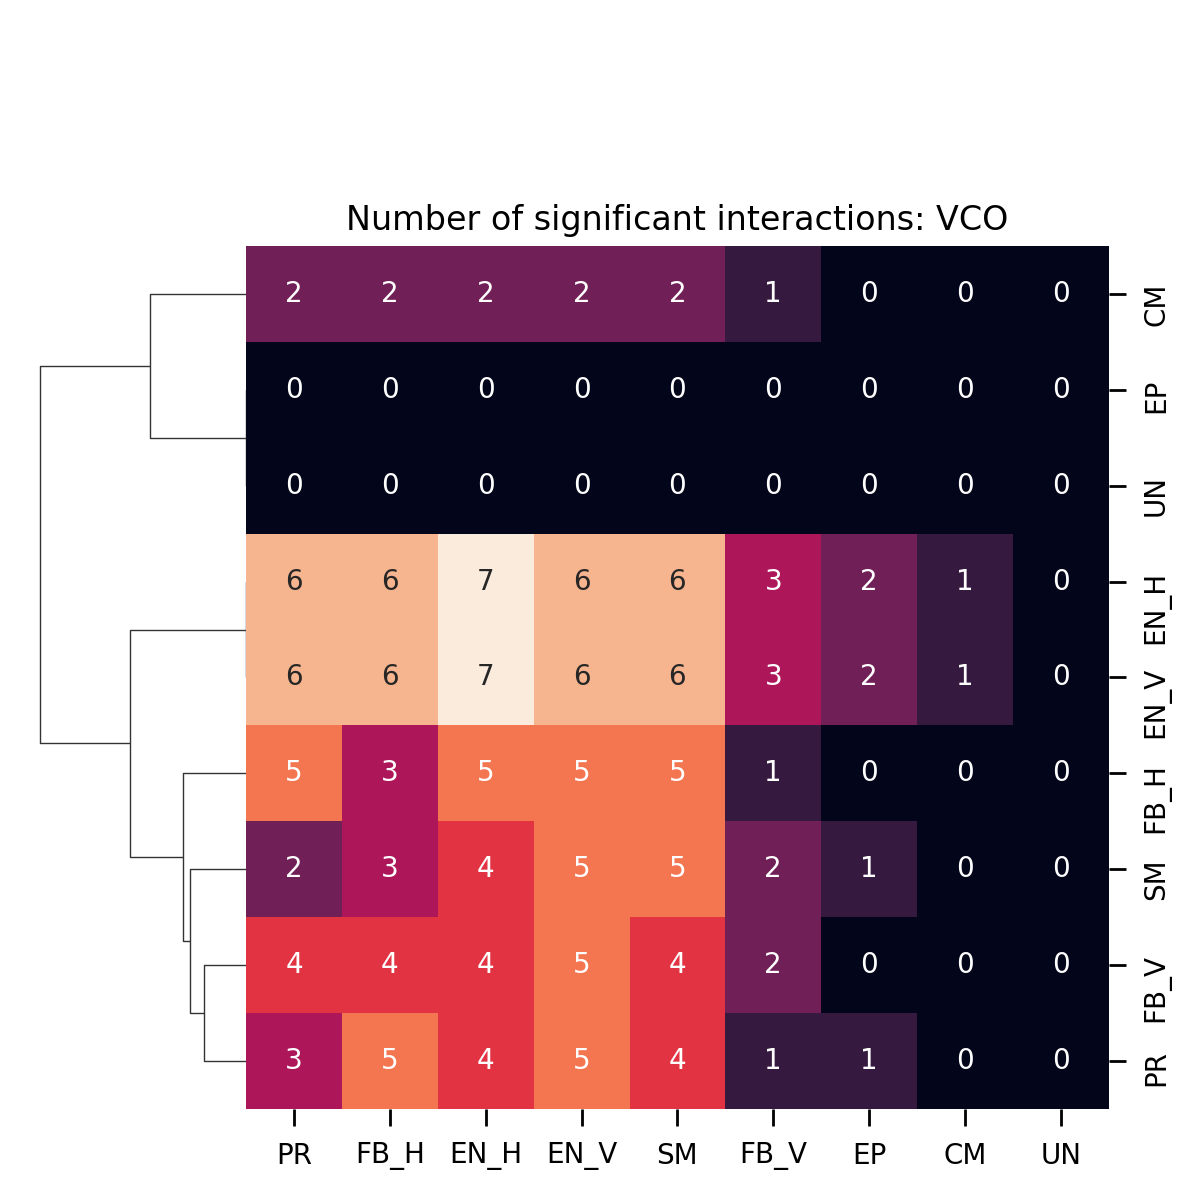

/home/herbert/PyProjects/cocultured_organ/workspace/CCO07/cpdb/HO.statistical


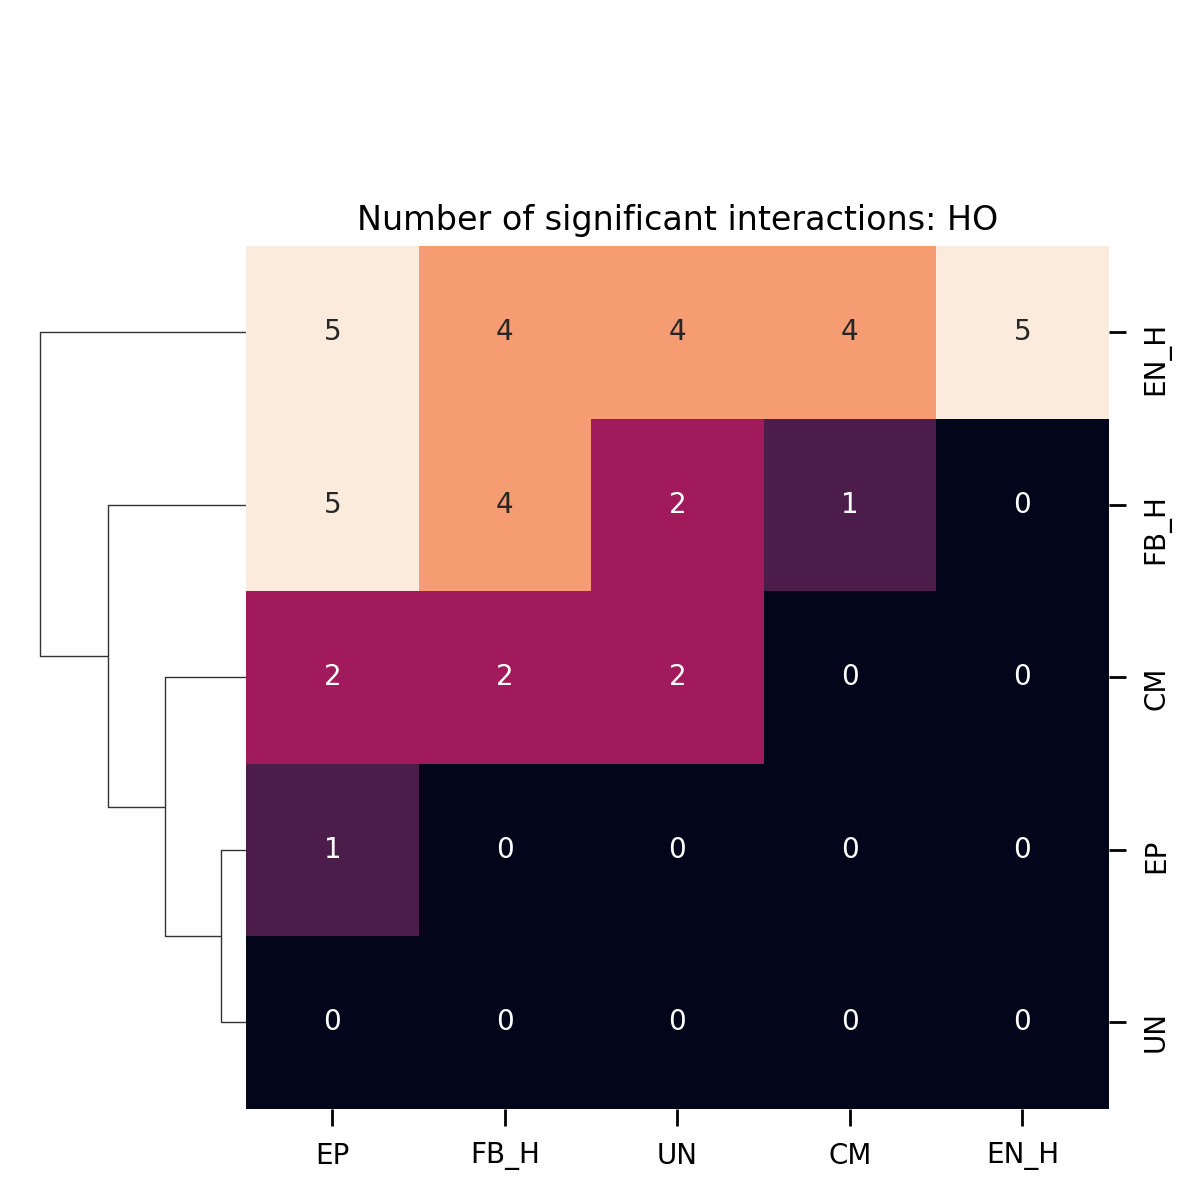

In [36]:
pattern = os.path.join(work_dir,"*.statistical")
for cpdb_dir in glob(pattern):
    print(cpdb_dir)
    label = os.path.basename(cpdb_dir).replace(".statistical","")
    pvals_path = glob(os.path.join(cpdb_dir,f"statistical_analysis_pvalues_{date}_*.txt"))[0]
    pvals_df = pd.read_csv(pvals_path,sep="\t")

    out = kpy.plot_cpdb_heatmap(
        pvals=pvals_df,
        symmetrical=False,
        return_tables=True
    )

    g = sns.clustermap(out["count_network"],annot=True,fmt='g',cbar=False,figsize=(6,6),cbar_pos=None,)
    g.ax_col_dendrogram.remove()
    g.ax_heatmap.set_title(f"Number of significant interactions: {label}")
    fig_path = os.path.join(figs_dir,f"{label}.n_signif_interactions_heatmap.png")
    plt.savefig(fig_path,dpi=300)
    plt.show()
    
    for cpdb_key in adata.obs["cpdb_key"].unique():
        df = kpy.plot_cpdb(
            adata=adata,
            cell_type1=cpdb_key,
            cell_type2=".",
            means=means_df,
            pvals=pvals_df,
            celltype_key="cpdb_key",
            highlight_size=1,
            figsize=(24,24),
            title=f"{label} {cpdb_key}",
            default_style=False,
            return_table=True
        )
        df.index = [index.replace(">@<","-") for index in df.index]
        df["interaction_group"] = [group.replace(">@<","-").split("---")[-1] for group in df["interaction_group"]]
        df["significant"] = df["significant"].fillna("no")
        df_path = os.path.join(cpdb_dir,f"{label}__{cpdb_key}.csv")
        df.to_csv(df_path)

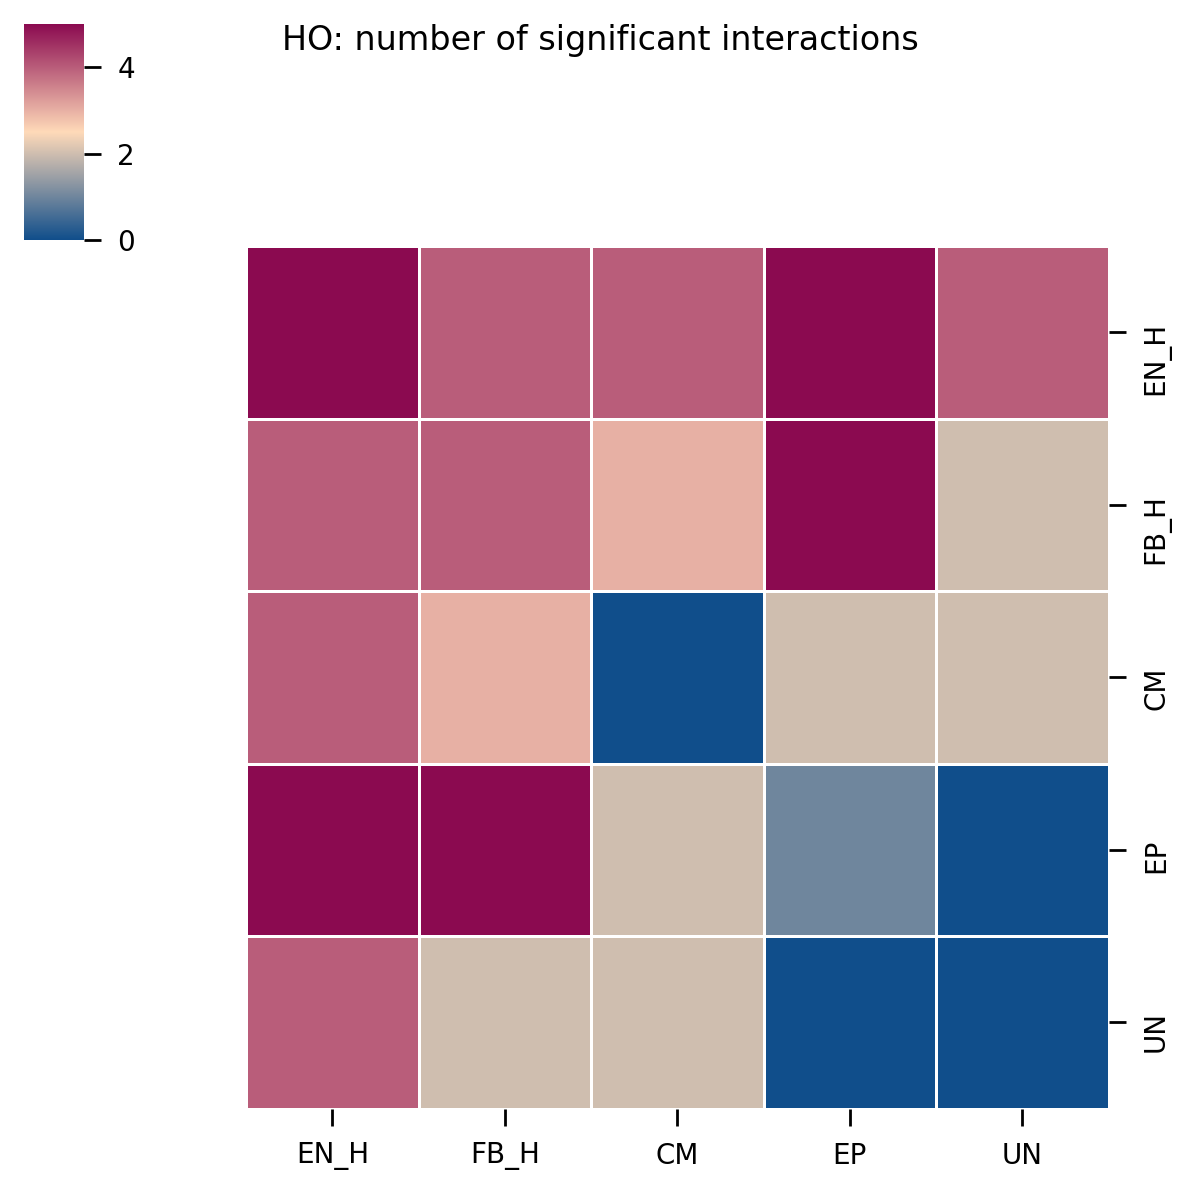

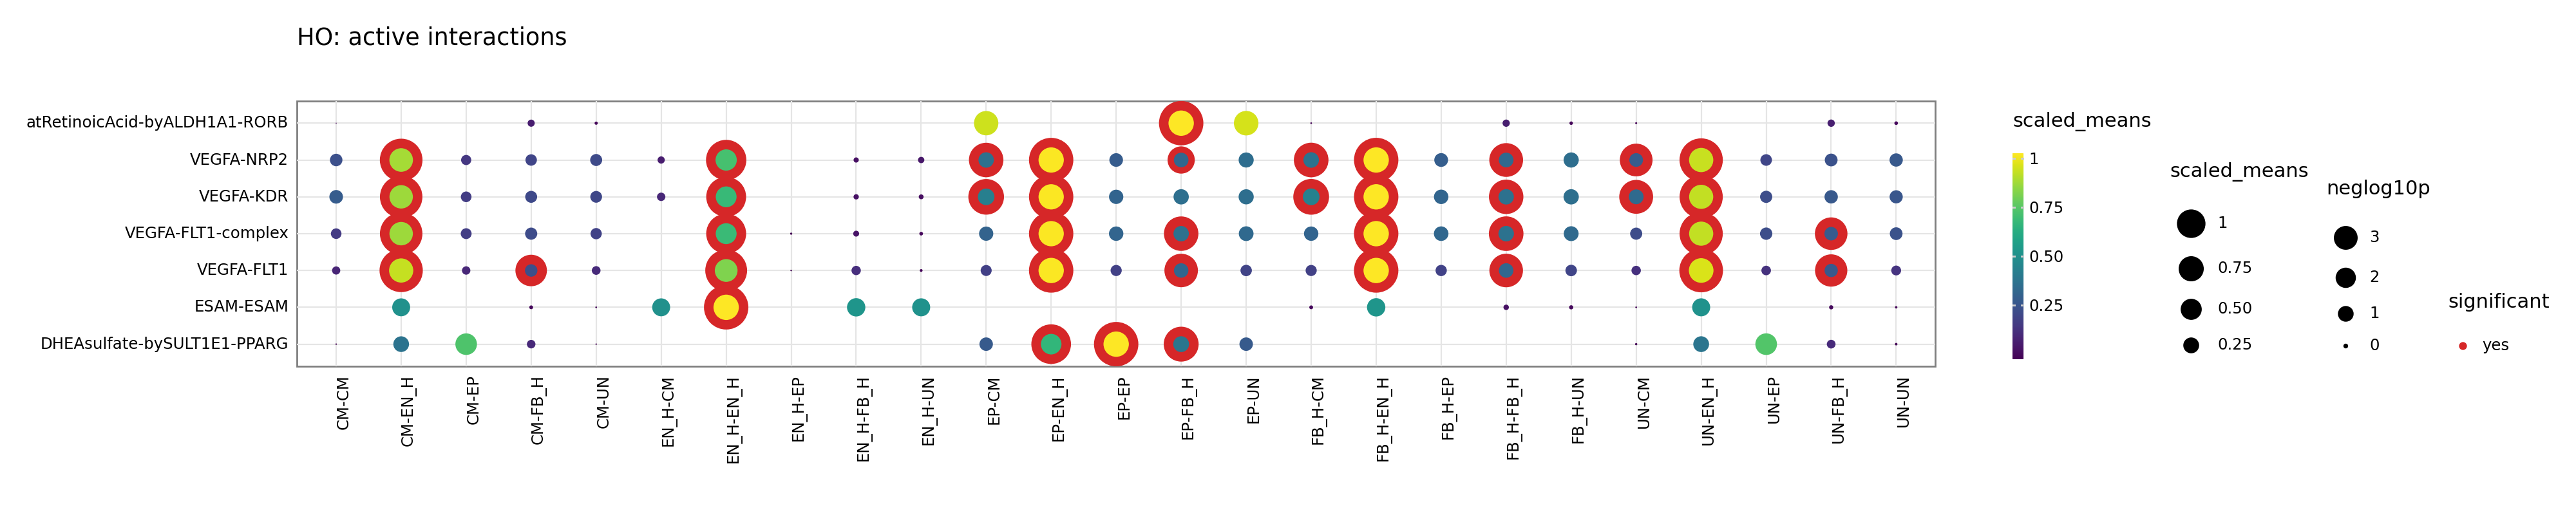

<Figure Size: (2000 x 400)>

In [21]:
if True:
    group = "HO"
    time = "08_01_2025_024644"
else:
    group = "VCO"
    time = "08_01_2025_024715"

adata = sc.read_h5ad(f"{work_dir}/adata/{group}.h5ad")
means = pd.read_csv(f"{work_dir}/{group}.statistical/statistical_analysis_means_{time}.txt", sep="\t")
pvals = pd.read_csv(f"{work_dir}/{group}.statistical/statistical_analysis_pvalues_{time}.txt", sep="\t")
decon = pd.read_csv(f"{work_dir}/{group}.statistical/statistical_analysis_deconvoluted_{time}.txt", sep="\t")

kpy.plot_cpdb_heatmap(pvals=pvals, figsize=(6, 6), title=f"{group}: number of significant interactions")
plt.show()

kpy.plot_cpdb(
    adata=adata,
    cell_type1=".",
    cell_type2=".",  # this means all cell-types
    keep_significant_only=True,
    means=means,
    pvals=pvals,
    celltype_key="cpdb_group",
    figsize=(20, 4),
    title=f"{group}: active interactions",
)

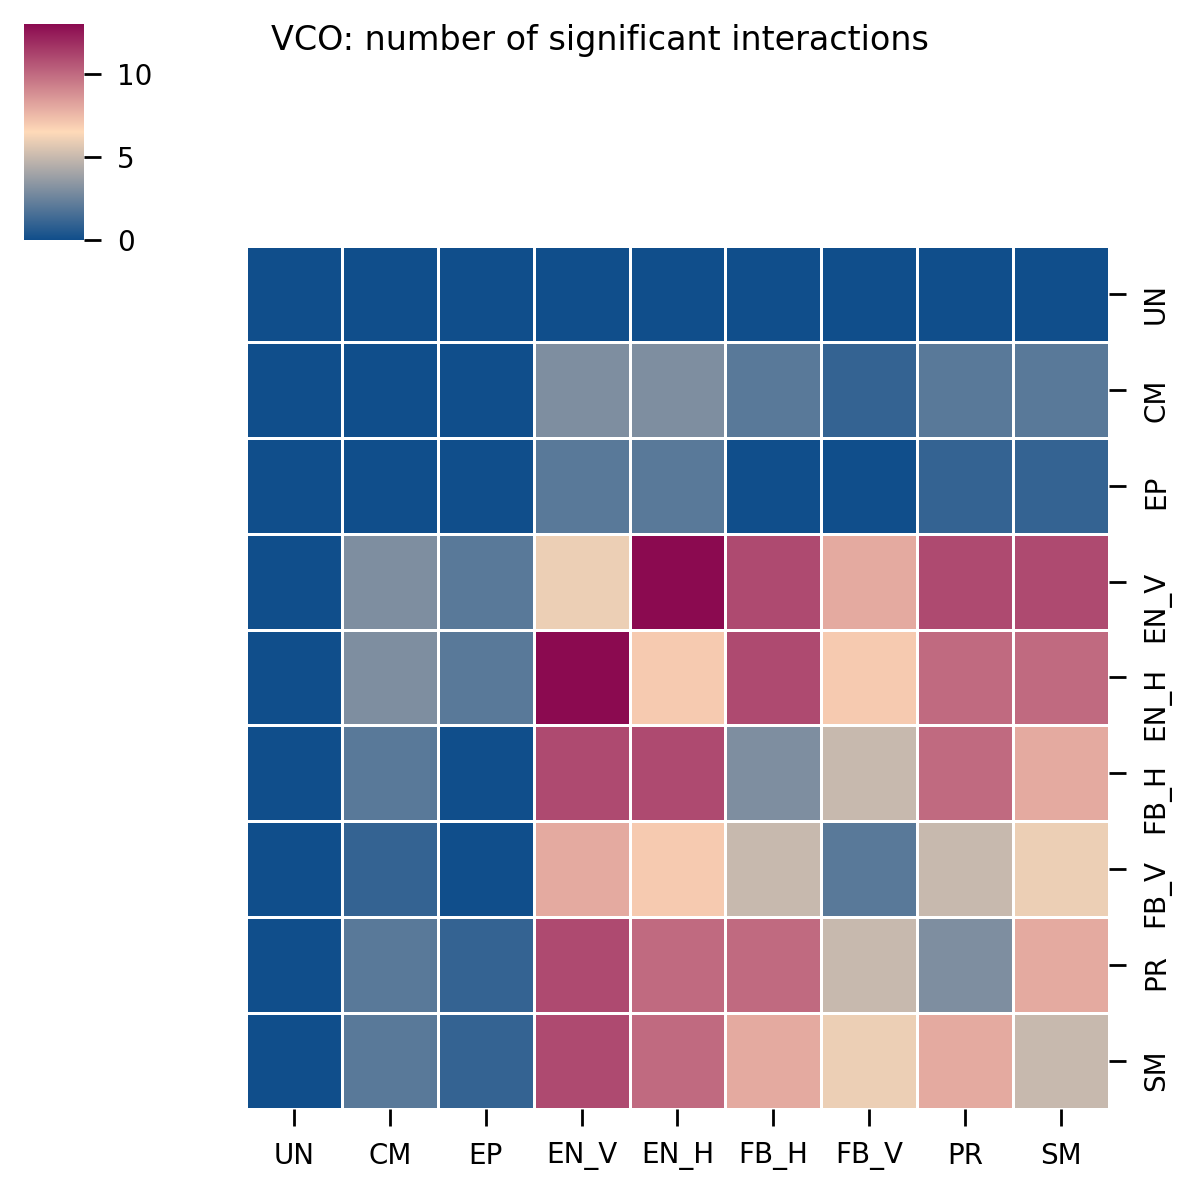

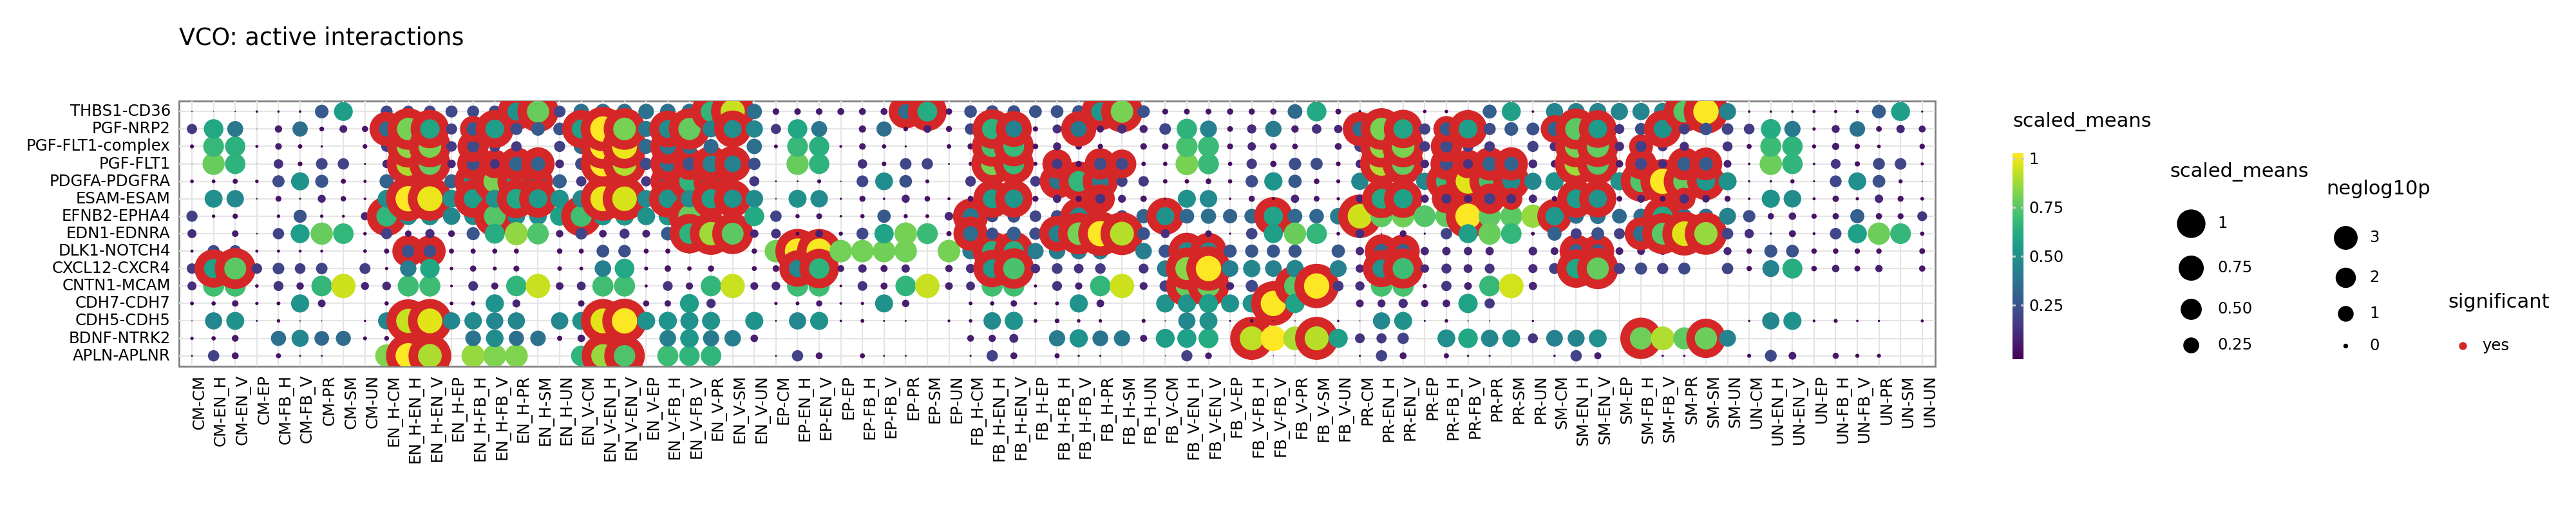

<Figure Size: (2000 x 400)>

In [22]:
if False:
    group = "HO"
    time = "08_01_2025_024644"
else:
    group = "VCO"
    time = "08_01_2025_024715"

adata = sc.read_h5ad(f"{work_dir}/adata/{group}.h5ad")
means = pd.read_csv(f"{work_dir}/{group}.statistical/statistical_analysis_means_{time}.txt", sep="\t")
pvals = pd.read_csv(f"{work_dir}/{group}.statistical/statistical_analysis_pvalues_{time}.txt", sep="\t")
decon = pd.read_csv(f"{work_dir}/{group}.statistical/statistical_analysis_deconvoluted_{time}.txt", sep="\t")

kpy.plot_cpdb_heatmap(pvals=pvals, figsize=(6, 6), title=f"{group}: number of significant interactions")
plt.show()

kpy.plot_cpdb(
    adata=adata,
    cell_type1=".",
    cell_type2=".",  # this means all cell-types
    keep_significant_only=True,
    means=means,
    pvals=pvals,
    celltype_key="cpdb_group",
    figsize=(20, 4),
    title=f"{group}: active interactions",
)